# 00. Imports & Functions

## Imports

In [43]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import torch.nn.functional as F
# import skfda, L2Regularization, LinearDifferentialOperator, BSplineBasis, BasisSmoother FOR WAVEFORM DATA

from ABRA_022626 import interpolate_and_smooth, CNN, plot_wave, calculate_and_plot_wave, plot_waves_single_frequency, arfread, get_str, calculate_hearing_threshold, all_thresholds, peak_finding

import pandas as pd
import sys
import zarr
import numpy as np
import time

import re
import io

import umap
import os
import torch
import aicsimageio

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
# from skfda.representation.basis import BSplineBasis
# from skfda.misc.regularization import L2Regularization
# from skfda.misc.operators import LinearDifferentialOperator
# from skfda.preprocessing.smoothing import BasisSmoother
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.cluster import KMeans
# from collections import defaultdict
# import skfda

from sklearn.metrics import mean_squared_error, r2_score

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import KFold, GroupKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



import struct
import datetime
# from skfda import FDataGrid
# from skfda.preprocessing.dim_reduction import FPCA
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import numpy as np
import pandas as pd
import struct
import matplotlib.pyplot as plt
import torch
from scipy.ndimage import gaussian_filter1d
import torch.nn as nn
# from tensorflow.keras.models import load_model
from scipy.interpolate import CubicSpline
from scipy.signal import find_peaks
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path
import torch
from PIL import Image
import random
# import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')
# import pytorch libraries
%matplotlib inline
import torch 
import torch.autograd as autograd 
import torch.nn as nn 
import torch.nn.functional as F
import torch.optim as optim
import numpy as np4
from sklearn.metrics import r2_score
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split


import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold, cross_val_score
import torchvision.transforms as transforms

## ABRA

In [44]:
def latency_all_peaks(highest_peaks, y_values, time_scale):
    latencies = []
    num_peaks = highest_peaks.size
    if num_peaks > 0:  # Check if highest_peaks is not empty
        for n in range(num_peaks): # SHOULD be 5 but there are cases where there are less. Will handle in later loops
            lat = highest_peaks[n] * (time_scale / len(y_values)) # Based on ABRA logic
            latencies.append(lat)
        return latencies
    else:
        print("No peaks detected. Check input data")
        return None

In [45]:
def full_interpolation(df, freq, db, time_scale=10, multiply_y_factor=1.0, units='Microvolts'):
    
    khz = df[(df['Freq(kHz)'] == freq) & (df['Level(dB)'] == db)]
    # print(khz)
    if not khz.empty:
        index = khz.index.values[0]
        final = df.loc[index, '0':].dropna()
        final = pd.to_numeric(final, errors='coerce').dropna()

        target = int(244 * (time_scale / 10))
        
        # Process the wave as in calculate_and_plot_wave
        y_values = interpolate_and_smooth(final, target)

        # print(f"Interpolated y_values: {y_values[:5]}")
        # print(f"Any NaNs? {np.isnan(y_values).any()}")

        if final.empty:
            print(f"Warning: Empty waveform for {freq}kHz @ {db}dB")
            return np.full((1, 244), np.nan)
        
        # Apply scaling factor
        y_values *= multiply_y_factor
        
        # Handle units conversion if needed
        if units == 'Nanovolts':
            y_values /= 1000
            
        # Generate normalized version for peak finding
        y_values_fpf = interpolate_and_smooth(y_values[:244])
        
        # Standardize and normalize for peak finding, exactly as in the original
        flattened_data = y_values_fpf.flatten().reshape(-1, 1)
        scaler = StandardScaler()
        standardized_data = scaler.fit_transform(flattened_data)
        min_max_scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = min_max_scaler.fit_transform(standardized_data).reshape(y_values_fpf.shape)
    
        return scaled_data

In [46]:
def peak_finding(wave):
    # Prepare waveform
    waveform=interpolate_and_smooth(wave) # Added indexing per calculate and plot wave function
    # waveform_torch = torch.tensor(waveform, dtype=torch.float32).unsqueeze(0) archived ABRA
    waveform_torch = torch.tensor(waveform, dtype=torch.float32).unsqueeze(0).unsqueeze(0) #newer ABRA
    # print(waveform_torch)
    # Get prediction from model
    outputs = peak_finding_model(waveform_torch)
    prediction = int(round(outputs.detach().numpy()[0][0], 0))
    # prediction_test = int(round(outputs.detach().numpy()[0], 0))
    # print("Model output:", outputs, "Prediction true start:", prediction)

    # Apply Gaussian smoothing
    smoothed_waveform = gaussian_filter1d(waveform, sigma=1)

    # Find peaks and troughs
    n = 18
    t = 14
    # start_point = prediction - 9 archived ABRA
    start_point = prediction - 6 #newer ABRA
    smoothed_peaks, _ = find_peaks(smoothed_waveform[start_point:], distance=n)
    smoothed_troughs, _ = find_peaks(-smoothed_waveform, distance=t)
    sorted_indices = np.argsort(smoothed_waveform[smoothed_peaks+start_point])
    highest_smoothed_peaks = np.sort(smoothed_peaks[sorted_indices[-5:]] + start_point)
    relevant_troughs = np.array([])
    for p in range(len(highest_smoothed_peaks)):
        c = 0
        for t in smoothed_troughs:
            if t > highest_smoothed_peaks[p]:
                if p != 4:
                    try:
                        if t < highest_smoothed_peaks[p+1]:
                            relevant_troughs = np.append(relevant_troughs, int(t))
                            break
                    except IndexError:
                        pass
                else:
                    relevant_troughs = np.append(relevant_troughs, int(t))
                    break
    relevant_troughs = relevant_troughs.astype('i')
    return highest_smoothed_peaks, relevant_troughs

def extract_metadata(metadata_lines):
    # Dictionary to store extracted metadata
    metadata = {}
    
    for line in metadata_lines:
        # Extract SW FREQ
        freq_match = re.search(r'SW FREQ:\s*(\d+\.?\d*)', line)
        if freq_match:
            metadata['SW_FREQ'] = float(freq_match.group(1))
        
        # Extract LEVELS
        levels_match = re.search(r':LEVELS:\s*([^:]+)', line)
        if levels_match:
            # Split levels and convert to list of floats
            metadata['LEVELS'] = [float(level) for level in levels_match.group(1).split(';') if level]
    
    return metadata

def read_custom_tsv(file_path):
    # Read the entire file
    with open(file_path, 'r', encoding='ISO-8859-1') as f:
        content = f.read()
    
    # Split the content into metadata and data sections
    metadata_lines = []
    data_section = None
    
    # Find the ':DATA' marker
    data_start = content.find(':DATA')
    
    if data_start != -1:
        # Extract metadata (lines before ':DATA')
        metadata_lines = content[:data_start].split('\n')
        
        # Extract data section
        data_section = content[data_start:].split(':DATA')[1].strip()
    
    # Extract specific metadata
    metadata = extract_metadata(metadata_lines)
    
    # Read the data section directly
    try:
        # Use StringIO to create a file-like object from the data section
        raw_data = pd.read_csv(
            io.StringIO(data_section), 
            sep='\s+',  # Use whitespace as separator
            header=None
        )
        raw_data = raw_data.T
        # Add metadata columns to the DataFrame
        if 'SW_FREQ' in metadata:
            raw_data['Freq(kHz)'] = metadata['SW_FREQ']
            # raw_data['Freq(Hz)'] = raw_data['Freq(Hz)'].apply(lambda x: x*1000)
        
        if 'LEVELS' in metadata:
            # Repeat levels to match the number of rows
            levels_repeated = metadata['LEVELS'] * (len(raw_data) // len(metadata['LEVELS']) + 1)
            raw_data['Level(dB)'] = levels_repeated[:len(raw_data)]
        
        filtered_data = raw_data.apply(pd.to_numeric, errors='coerce').dropna()
        filtered_data.columns = filtered_data.columns.map(str)

        columns = ['Freq(kHz)'] + ['Level(dB)'] + [col for col in filtered_data.columns if col.isnumeric() == True]
        filtered_data = filtered_data[columns]
        return filtered_data
    
    except Exception as e:
        print(f"Error reading data: {e}")
        return None, metadata

In [47]:
def peaks_troughs_amp_final(df, freq, db, time_scale=10, multiply_y_factor=1.0, units='Microvolts'):
    db_column = 'Level(dB)'
    
    khz = df[(df['Freq(kHz)'] == freq) & (df[db_column] == db)]
    if not khz.empty:
        index = khz.index.values[0]
        final = df.loc[index, '0':].dropna()
        final = pd.to_numeric(final, errors='coerce').dropna()

        target = int(244 * (time_scale / 10))
        
        # Process the wave as in calculate_and_plot_wave
        y_values = interpolate_and_smooth(final, target)
        
        # Apply scaling factor
        y_values *= multiply_y_factor
        
        # Handle units conversion if needed
        if units == 'Nanovolts':
            y_values /= 1000
            
        # Generate normalized version for peak finding
        y_values_fpf = interpolate_and_smooth(y_values[:244])
        
        # Standardize and normalize for peak finding, exactly as in the original
        flattened_data = y_values_fpf.flatten().reshape(-1, 1)
        scaler = StandardScaler()
        standardized_data = scaler.fit_transform(flattened_data)
        min_max_scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = min_max_scaler.fit_transform(standardized_data).reshape(y_values_fpf.shape)
        y_values_fpf = interpolate_and_smooth(scaled_data[:244])
        
        # Find peaks using the normalized data
        highest_peaks, relevant_troughs = peak_finding(y_values_fpf)
        
        # Calculate amplitude on the processed but non-normalized data
        if highest_peaks.size > 0 and relevant_troughs.size > 0:
            # Following the same approach as in the display_metrics_table function
            first_peak_amplitude = y_values[highest_peaks[0]] - y_values[relevant_troughs[0]]
            return highest_peaks, relevant_troughs, first_peak_amplitude
    
    return None, None, None

## Data Loading

In [48]:

def normalize(data, maxval=1., dtype=np.uint16):
    data = data.astype(dtype)
    data_norm = data - data.min()
    scale_fact = maxval/data_norm.max()
    data_norm = data_norm * scale_fact
    return data_norm.astype(dtype)


In [49]:
class SynapseImageDataset(Dataset):
    """
    Dataset that handles v1/v2 pairing from filenames.
    Skips files that cannot be loaded.
    """
    def __init__(self, image_paths, ch_order=['myo7', 'glur2', 'ctbp2', 'nf'], 
                 target_size=224):
        self.ch_order = ch_order
        self.target_size = target_size
        self.resize = transforms.Resize((target_size, target_size))
        
        # Build pairing dictionary
        self.pairs = {}  # Maps each file to its pair
        self.image_paths = []
        
        for path in image_paths:

            if not path.endswith('.lif'):
                continue
            
            self.image_paths.append(path)
            
            # Extract base name and version
            if '.v1.lif' in path:
                base = path.replace('.v1.lif', '')
                pair_path = base + '.v2.lif'

            elif '.v2.lif' in path:
                base = path.replace('.v2.lif', '')
                pair_path = base + '.v1.lif'

            else:
                # No version in filename, skip pairing
                continue
            
            # Store the pairing
            self.pairs[path] = pair_path
        
        print(f"Dataset: {len(self.image_paths)} images, {len(self.pairs)} with pairs")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        """
        Returns: Single tensor [4, H, W]
        Returns None if file cannot be loaded (error already printed by convert_max_proj_tensor)
        """
        img_path = self.image_paths[idx]
        tensor = convert_max_proj_tensor(img_path, self.ch_order)
        
        # If loading failed, return None
        if tensor is None:
            return None
            
        tensor = normalize_per_channel(tensor)
        tensor = self.resize(tensor.unsqueeze(0)).squeeze(0)
        return tensor
    
    def get_pair(self, idx):
        """
        Get the paired image for index idx.
        Returns (image, pair_image) or (None, None) if loading fails.
        If pair doesn't exist or fails to load, returns (image, None).
        """
        # Get original image
        img_path = self.image_paths[idx]
        img = self[idx]
        
        # If original image failed to load, return (None, None)
        if img is None:
            print(f"  Skipping pair lookup - original image failed to load")
            return None, None
        
        # Check if pair exists
        if img_path not in self.pairs:
            return img, None
        
        pair_path = self.pairs[img_path]
        
        # Load pair image
        if pair_path in self.image_paths:
            pair_idx = self.image_paths.index(pair_path)
            pair_img = self[pair_idx]
            
            if pair_img is None:
                print(f"  Pair image failed to load: {pair_path}")
                return img, None
                
            return img, pair_img
        else:
            return img, None


def collate_fn_skip_none(batch):
    """
    Custom collate function that filters out None values from batches.
    This allows the DataLoader to skip corrupted images that failed to load.
    """
    # Filter out None values
    batch = [item for item in batch if item is not None]
    
    # If all items were None, return empty batch
    if len(batch) == 0:
        return torch.empty(0)
    
    # Stack remaining valid tensors
    return torch.stack(batch, 0)


def create_dataloader(image_paths, batch_size=8, shuffle=True, augment=False, 
                      num_workers=0, target_size=224):
    """
    Create PyTorch DataLoader for synapse images.
    
    Args:
        image_paths: List of .lif file paths
        batch_size: Batch size for training
        shuffle: Shuffle data
        augment: Apply augmentations (for Shallow CNN training)
        num_workers: Number of parallel workers
        target_size: Image size
    
    Returns:
        DataLoader object
    """
    dataset = SynapseImageDataset(
        image_paths=image_paths,
        target_size=target_size
    )
    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False,
        collate_fn=collate_fn_skip_none  # Custom collate to skip None values
    )
    
    return dataloader


def collect_all_lif_paths(data_dir, subjects=None):
    """
    Collect all .lif file paths from directory structure.
    
    Args:
        data_dir: Base directory (e.g., liberman_data/Confocal Data Charles Liberman/)
        subjects: Optional list of subject IDs to include (e.g., ['WPZ116', 'WPZ145'])
                  If None, include all subjects
    
    Returns:
        List of full paths to .lif files
    """
    lif_paths = []
    
    for subject_dir in os.listdir(data_dir):
        subject_path = os.path.join(data_dir, subject_dir)
        
        # Filter by subjects if specified
        if subjects is not None and subject_dir not in subjects:
            continue
        
        if os.path.isdir(subject_path):
            for file_name in os.listdir(subject_path):
                if file_name.endswith('.lif'):
                    full_path = os.path.join(subject_path, file_name)
                    lif_paths.append(full_path)
    
    print(f"Found {len(lif_paths)} .lif files")
    return lif_paths


## Clustering

In [50]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def cluster_embeddings(embeddings, method='kmeans', n_clusters=5, **kwargs):
    """
    Cluster embeddings using various algorithms.
    
    Args:
        embeddings: numpy array of shape [n_samples, embedding_dim]
        method: 'kmeans', 'dbscan', or 'hierarchical'
        n_clusters: Number of clusters (for kmeans/hierarchical)
        **kwargs: Additional arguments for clustering algorithm
    
    Returns:
        cluster_labels: Array of cluster assignments
        cluster_model: Fitted clustering model
    """
    if method == 'kmeans':
        model = KMeans(n_clusters=n_clusters, random_state=42, **kwargs)
        labels = model.fit_predict(embeddings)
        
    elif method == 'dbscan':
        from sklearn.cluster import DBSCAN
        eps = kwargs.get('eps', 0.5)
        min_samples = kwargs.get('min_samples', 5)
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(embeddings)
        
    elif method == 'hierarchical':
        from sklearn.cluster import AgglomerativeClustering
        linkage = kwargs.get('linkage', 'ward')
        model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
        labels = model.fit_predict(embeddings)
    
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Calculate silhouette score if we have multiple clusters
    n_unique = len(np.unique(labels))
    if n_unique > 1 and n_unique < len(embeddings):
        sil_score = silhouette_score(embeddings, labels)
        print(f"Silhouette Score: {sil_score:.3f}")
    else:
        print(f"Warning: Only {n_unique} unique cluster(s) found")
    
    return labels, model


def find_optimal_clusters(embeddings, max_k=10, method='kmeans'):
    """
    Find optimal number of clusters using elbow method and silhouette score.
    
    Args:
        embeddings: numpy array of embeddings
        max_k: Maximum number of clusters to try
        method: Clustering method
    
    Returns:
        Dictionary with scores for each k
    """
    results = {
        'k_values': [],
        'inertias': [],
        'silhouette_scores': []
    }
    
    for k in range(2, max_k + 1):
        labels, model = cluster_embeddings(embeddings, method=method, n_clusters=k)
        
        results['k_values'].append(k)
        
        if hasattr(model, 'inertia_'):
            results['inertias'].append(model.inertia_)
        
        if len(np.unique(labels)) > 1:
            sil = silhouette_score(embeddings, labels)
            results['silhouette_scores'].append(sil)
        else:
            results['silhouette_scores'].append(0)
        
        print(f"k={k}: Silhouette={results['silhouette_scores'][-1]:.3f}")
    
    return results


def analyze_clusters(embeddings, labels, metadata_df=None, metadata_cols=None):
    """
    Analyze cluster composition.
    
    Args:
        embeddings: numpy array of embeddings
        labels: Cluster labels
        metadata_df: DataFrame with metadata (subjects, freqs, groups, etc.)
        metadata_cols: List of column names to analyze
    
    Returns:
        Dictionary with cluster statistics
    """
    n_clusters = len(np.unique(labels))
    print(f"\n{'='*60}")
    print(f"CLUSTER ANALYSIS: {n_clusters} clusters found")
    print(f"{'='*60}\n")
    
    for cluster_id in np.unique(labels):
        mask = labels == cluster_id
        n_samples = np.sum(mask)
        
        print(f"Cluster {cluster_id}: {n_samples} samples ({100*n_samples/len(labels):.1f}%)")
        
        if metadata_df is not None and metadata_cols is not None:
            cluster_metadata = metadata_df[mask]
            
            for col in metadata_cols:
                if col in cluster_metadata.columns:
                    value_counts = cluster_metadata[col].value_counts()
                    print(f"  {col}: {dict(value_counts)}")
        
        print()
    
    return labels


def compare_clusters_to_experimental_groups(labels, group_labels, group_names=None):
    """
    Compare discovered clusters to known experimental groups.
    
    Args:
        labels: Cluster assignments
        group_labels: True experimental group labels
        group_names: Optional names for groups
    
    Returns:
        Confusion matrix and purity scores
    """
    from sklearn.metrics import confusion_matrix, adjusted_rand_score
    
    # Confusion matrix
    cm = confusion_matrix(group_labels, labels)
    
    # Adjusted Rand Index (similarity between clusterings)
    ari = adjusted_rand_score(group_labels, labels)
    
    print(f"Adjusted Rand Index: {ari:.3f}")
    print(f"(1.0 = perfect match, 0.0 = random, <0 = worse than random)")
    
    print(f"\nConfusion Matrix:")
    print(cm)
    
    return cm, ari

## Cluster Visualization

In [51]:
from sklearn.manifold import TSNE

def visualize_embeddings_2d(embeddings, labels=None, method='umap', title='Embedding Visualization',
                            colors=None, figsize=(10, 8), save_path=None):
    """
    Visualize high-dimensional embeddings in 2D.
    
    Args:
        embeddings: numpy array of shape [n_samples, embedding_dim]
        labels: Optional cluster labels or experimental groups
        method: 'umap' or 'tsne'
        title: Plot title
        colors: Optional custom colors for each point
        figsize: Figure size
        save_path: Optional path to save figure
    
    Returns:
        2D embedding coordinates
    """
    print(f"Reducing {embeddings.shape[1]}D embeddings to 2D using {method.upper()}...")
    
    if method == 'umap':
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
        embedding_2d = reducer.fit_transform(embeddings)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, random_state=42, perplexity=30)
        embedding_2d = reducer.fit_transform(embeddings)
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Plot
    plt.figure(figsize=figsize)
    
    if labels is not None:
        unique_labels = np.unique(labels)
        cmap = plt.cm.get_cmap('tab10', len(unique_labels))
        
        for i, label in enumerate(unique_labels):
            mask = labels == label
            plt.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], 
                       c=[cmap(i)], label=f'Cluster {label}', 
                       alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
        plt.legend()
    else:
        plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], 
                   c=colors, alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
    
    plt.xlabel(f'{method.upper()} 1')
    plt.ylabel(f'{method.upper()} 2')
    plt.title(title)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()
    
    return embedding_2d


def visualize_reconstructions(model, dataloader, n_samples=5, model_type='vae', device='mps'):
    """
    Visualize original vs reconstructed images.
    
    Args:
        model: Trained autoencoder or VAE
        dataloader: DataLoader with images
        n_samples: Number of samples to visualize
        model_type: 'autoencoder' or 'vae'
        device: 'cpu' or 'cuda'
    """
    model = model.to(device)
    model.eval()
    
    # Get batch of images
    for batch in dataloader:
        if isinstance(batch, (list, tuple)):
            images = batch[0]
        else:
            images = batch
        images = images.to(device)
        break
    
    # Reconstruct
    with torch.no_grad():
        if model_type == 'vae':
            reconstructions, mu, logvar = model(images)
        else:
            reconstructions, _ = model(images)
    
    # Move to CPU for visualization
    images = images.mps().numpy()
    reconstructions = reconstructions.mps().numpy()
    
    # Plot
    n_samples = min(n_samples, images.shape[0])
    fig, axes = plt.subplots(n_samples, 8, figsize=(20, 2.5*n_samples))
    
    channel_names = ['Myo7', 'GluR2', 'CtBP2', 'NF']
    
    for i in range(n_samples):
        for ch in range(4):
            # Original
            axes[i, ch].imshow(images[i, ch], cmap='gray')
            axes[i, ch].axis('off')
            if i == 0:
                axes[i, ch].set_title(f'Original\n{channel_names[ch]}')
            
            # Reconstructed
            axes[i, ch+4].imshow(reconstructions[i, ch], cmap='gray')
            axes[i, ch+4].axis('off')
            if i == 0:
                axes[i, ch+4].set_title(f'Reconstructed\n{channel_names[ch]}')
    
    plt.tight_layout()
    plt.suptitle('Original vs Reconstructed Images', y=1.01, fontsize=14)
    plt.show()


def plot_training_curves(losses, model_name='Model'):
    """
    Plot training loss curves.
    
    Args:
        losses: Loss dictionary or list from training
        model_name: Name for plot title
    """
    plt.figure(figsize=(10, 5))
    
    if isinstance(losses, dict):
        # VAE with multiple loss components
        plt.subplot(1, 2, 1)
        plt.plot(losses['total'], label='Total Loss')
        plt.plot(losses['recon'], label='Reconstruction')
        plt.plot(losses['kl'], label='KL Divergence')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'{model_name} - Loss Components')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.plot(losses['total'])
        plt.xlabel('Epoch')
        plt.ylabel('Total Loss')
        plt.title(f'{model_name} - Total Loss')
        plt.grid(True, alpha=0.3)
    else:
        # Simple loss list
        plt.plot(losses)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'{model_name} - Training Loss')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_cluster_quality(results):
    """
    Plot elbow curve and silhouette scores for cluster selection.
    
    Args:
        results: Dictionary from find_optimal_clusters()
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Elbow plot
    if len(results['inertias']) > 0:
        axes[0].plot(results['k_values'], results['inertias'], 'bo-')
        axes[0].set_xlabel('Number of Clusters (k)')
        axes[0].set_ylabel('Inertia')
        axes[0].set_title('Elbow Method')
        axes[0].grid(True, alpha=0.3)
    
    # Silhouette scores
    axes[1].plot(results['k_values'], results['silhouette_scores'], 'ro-')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Analysis')
    axes[1].axhline(y=0.5, color='g', linestyle='--', label='Good separation (>0.5)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Recommend best k
    best_k_idx = np.argmax(results['silhouette_scores'])
    best_k = results['k_values'][best_k_idx]
    best_score = results['silhouette_scores'][best_k_idx]
    
    print(f"\nRecommended k: {best_k} (silhouette score: {best_score:.3f})")


def visualize_latent_space_sampling(vae_model, n_samples=10, latent_dim=256, device='mps'):
    """
    Sample random points from VAE latent space and decode.
    
    Useful for understanding what the VAE learned.
    """
    vae_model = vae_model.to(device)
    vae_model.eval()
    
    # Sample from standard normal
    z = torch.randn(n_samples, latent_dim).to(device)
    
    with torch.no_grad():
        generated = vae_model.decode(z)
    
    generated = generated.mps().numpy()
    
    # Visualize
    fig, axes = plt.subplots(n_samples, 4, figsize=(12, 3*n_samples))
    channel_names = ['Myo7', 'GluR2', 'CtBP2', 'NF']
    
    for i in range(n_samples):
        for ch in range(4):
            axes[i, ch].imshow(generated[i, ch], cmap='gray')
            axes[i, ch].axis('off')
            if i == 0:
                axes[i, ch].set_title(f'{channel_names[ch]}')
    
    plt.tight_layout()
    plt.suptitle('Random Samples from VAE Latent Space', y=1.01, fontsize=14)
    plt.show()

## Embedding Helper

In [52]:
# Helper functions for embedding pipeline

def convert_max_proj_tensor(file_path, ch_order):
    """
    Convert .lif file to max projection tensor.
    Returns None if file cannot be loaded (with error message printed).
    """
    try:
        start_t = time.time()
        last_t = start_t
        count = 0

        reader = aicsimageio.AICSImage(file_path)

        all_channels = []   

        for ch in range(reader.shape[1]):
            ch_name = ch_order[ch]
            
            channel_data = reader.get_image_data("CZYX", C=ch)
            channel_data = np.squeeze(channel_data, axis=0) 
            if ch_name == 'ctbp2':
                channel_data = normalize(channel_data.astype(np.uint16), maxval=(2**16-1)).astype(np.uint16)

            max_proj = np.max(channel_data, axis=0)
            all_channels.append(max_proj)

            count += 1
            last_t = time.time()

        # Stack channels: list of (H, W) → (C, H, W)
        image_3d = np.stack(all_channels, axis=0)
        tensor = torch.from_numpy(image_3d).float()
                    
        return tensor
        
    except ValueError as e:
        print(f"ERROR: ValueError loading {file_path}")
        print(f"  Details: {e}")
        return None
    except OSError as e:
        print(f"ERROR: OSError loading {file_path}")
        print(f"  Details: {e}")
        return None
    except Exception as e:
        print(f"ERROR: Unexpected error loading {file_path}")
        print(f"  Details: {type(e).__name__}: {e}")
        return None


def normalize_per_channel(tensor):
    """
    Normalize each channel independently to [0, 1].
    
    Args:
        tensor: Shape [C, H, W]
    
    Returns:
        Normalized tensor of same shape
    """
    normalized = torch.zeros_like(tensor)
    
    for c in range(tensor.shape[0]):
        channel = tensor[c]
        normalized[c] = (channel - channel.min()) / (channel.max() - channel.min() + 1e-8)
    
    return normalized


def get_embedding_multi_channel(img_tensor, embedder, resize_to=(224, 224)):
    """
    Generate embedding from multi-channel image.
    
    Args:
        img_tensor: Tensor of shape [C, H, W]
        embedder: Multi-channel PyTorch model
        resize_to: Target size for model input
    
    Returns:
        Embedding vector of shape [embedding_dim]
    """
    transform = transforms.Compose([
        transforms.Resize(resize_to),
    ])
    
    # Add batch dimension: [C, H, W] → [1, C, H, W]
    img_batch = img_tensor.unsqueeze(0)
    img_resized = transform(img_batch)
    
    # Generate embedding
    with torch.no_grad():
        embedding = embedder(img_resized)
    
    # Remove batch dimension: [1, embedding_dim] → [embedding_dim]
    return embedding.squeeze(0)


def embedding_to_numpy(embedding_tensor):
    """
    Convert PyTorch tensor embedding to numpy array.
    
    Args:
        embedding_tensor: PyTorch tensor (can be on GPU or CPU)
    
    Returns:
        numpy array (always on CPU)
    """
    # Move to CPU if on GPU, then convert to numpy
    return embedding_tensor.mps().detach().numpy()


In [53]:
def process_image_to_embedding(embedder, key, data_dir, ch_order, export_embeddings=False, convert_to_tensor=False):
    all_arrays = []
    for dir_name in os.listdir(data_dir):
            # check if dir_name is in key ID column
            if dir_name in key["ID"].values:
                # groups = key[key["ID"] == dir_name]["Group"].values[0]
                continue
            else:
                print(f"{dir_name} not found in key")
            
            for file_name in os.listdir(os.path.join(data_dir, dir_name)):
                if file_name.endswith(".lif"):
                    # freq = file_name.split(".")[6]+"."+file_name.split(".")[7]
                    # view = file_name.split(".")[8]

                    file_path = os.path.join(data_dir, dir_name, file_name)
                    tensor = convert_max_proj_tensor(file_path, ch_order)
                    normalized_tensor = normalize_per_channel(tensor)
                    embedding = get_embedding_multi_channel(normalized_tensor, embedder)
                    embedding_numpy = embedding_to_numpy(embedding)
                    all_arrays.append(embedding_numpy)

                    if export_embeddings:
                        np.save(f'embedding_v1.npy', embedding_numpy) #figure out naming convention
    
    all_embeddings = np.stack(all_arrays)
    
    if convert_to_tensor:
        torch_batch = torch.from_numpy(all_embeddings).float()
        print(f"Batch of embeddings{all_embeddings.shape} (batch_size=2, embedding_dim=512)\n[NOTE: Returned as torch tensor]")
        return torch_batch

    print(f"Batch of embeddings: {all_embeddings.shape} (batch_size=2, embedding_dim=512)")

    return all_embeddings
                # how to stack and export tensors effectively?

                # out_zarr = os.path.join("./zarrs", "liberman", group.replace(" ", "_"), f"{dir_name}_{freq}_{view}.zarr")
                # if not os.path.exists(os.path.join(out_zarr, 'ctbp2')):
                #     count += 1
                #     print(count, f"Saving {file_name} to {out_zarr}")
                #     out = zarr.open(out_zarr, 'a')
                
# np.load('.npy') to load later                    

## Embedding-Metadata Integration

In [54]:
# ============================================================================
# Image Metadata Extraction and Clustering Integration
# ============================================================================
# Connect clustering results with experimental metadata to interpret findings

import re
import os

def parse_image_metadata(file_path):
    """
    Extract metadata from .lif file path.

    File naming convention:
    [SubjectID]L.CtBP2.GluR2.NF.Myo7.IHC.[Frequency].[View].lif
    Example: WPZ116L.CtBP2.GluR2.NF.Myo7.IHC.45.2.v1.lif

    Args:
        file_path: Full path to .lif file

    Returns:
        dict with keys: 'subject', 'frequency', 'view', 'file_path'
    """
    filename = os.path.basename(file_path)

    # Extract subject (e.g., WPZ116)
    subject_match = re.match(r'(WPZ\d+)', filename)
    subject = subject_match.group(1) if subject_match else None

    # Extract frequency (e.g., 45.2 or 8.0)
    freq_match = re.search(r'IHC\.(\d+\.\d+|\d+)\.v', filename)
    frequency = float(freq_match.group(1)) if freq_match else None

    # Extract view (v1 or v2)
    view_match = re.search(r'\.(v[12])\.lif', filename)
    view = view_match.group(1) if view_match else None

    return {
        'subject': subject,
        'frequency': frequency,
        'view': view,
        'file_path': file_path,
        'filename': filename
    }


def create_metadata_dataframe(image_paths, experimental_metadata=None):
    """
    Create DataFrame with metadata for all images.

    Args:
        image_paths: List of .lif file paths
        experimental_metadata: Can be:
            - Path to WPZ Mouse groups.xlsx (string)
            - Pre-loaded DataFrame with subject metadata
            - None (will only parse image paths)

    Returns:
        pandas DataFrame with columns: subject, frequency, view, file_path,
        and optionally: Group, Strain, and other metadata columns
    """
    # Parse all image paths
    metadata_list = []
    for path in image_paths:
        meta = parse_image_metadata(path)
        metadata_list.append(meta)

    df = pd.DataFrame(metadata_list)

    # Handle experimental metadata
    if experimental_metadata is not None:
        if isinstance(experimental_metadata, str):
            # It's a file path
            if os.path.exists(experimental_metadata):
                exp_meta = pd.read_excel(experimental_metadata)
                exp_meta = exp_meta.rename(columns={'ID#': 'subject'})
                exp_meta['Group'] = exp_meta['Group'].str.strip()
                exp_meta['Strain'] = exp_meta['Strain'].str.strip()
                
                # Merge on subject ID
                df = df.merge(exp_meta[['subject', 'Group', 'Strain']], on='subject', how='left')
        
        elif isinstance(experimental_metadata, pd.DataFrame):
            # It's already a DataFrame
            exp_meta = experimental_metadata.copy()
            
            # Standardize column names
            rename_map = {}
            if 'Subject' in exp_meta.columns:
                rename_map['Subject'] = 'subject'
            if 'Freq(kHz) (x1)' in exp_meta.columns:
                rename_map['Freq(kHz) (x1)'] = 'frequency'
            if 'Strain (x5)' in exp_meta.columns:
                rename_map['Strain (x5)'] = 'Strain'
            
            if rename_map:
                exp_meta = exp_meta.rename(columns=rename_map)
            
            # Identify which columns to merge
            merge_cols = ['subject']
            if 'subject' not in exp_meta.columns and 'Subject' not in exp_meta.columns:
                print("Warning: No 'subject' or 'Subject' column found in experimental_metadata")
                return df
            
            # Add other useful columns if they exist
            for col in ['Group', 'Strain', 'vx (x4)', 'Synapses to IHC (y1)', 'IHCs']:
                if col in exp_meta.columns and col not in merge_cols:
                    merge_cols.append(col)
            
            # Merge - use both subject and frequency if available for better matching
            if 'frequency' in exp_meta.columns:
                # Merge on both subject and frequency
                df = df.merge(
                    exp_meta[merge_cols + ['frequency']].drop_duplicates(subset=['subject', 'frequency']), 
                    on=['subject', 'frequency'], 
                    how='left'
                )
            else:
                # Merge on subject only (will create duplicates if subject has multiple freqs)
                df = df.merge(
                    exp_meta[merge_cols].drop_duplicates(subset=['subject']), 
                    on='subject', 
                    how='left'
                )

    return df


def merge_clusters_with_metadata(embeddings, cluster_labels, image_paths,
                                  experimental_metadata=None):
    """
    Create comprehensive DataFrame combining embeddings, clusters, and metadata.

    Args:
        embeddings: numpy array [n_samples, embedding_dim]
        cluster_labels: numpy array [n_samples] with cluster assignments
        image_paths: List of .lif file paths (same order as embeddings)
        experimental_metadata: Path to Excel file or DataFrame with experimental data

    Returns:
        pandas DataFrame with all information combined
    """
    # Get metadata
    metadata_df = create_metadata_dataframe(image_paths, experimental_metadata)

    # Add cluster labels
    metadata_df['cluster'] = cluster_labels

    # Add embedding coordinates (useful for plotting)
    for i in range(min(embeddings.shape[1], 10)):  # Store first 10 dims
        metadata_df[f'emb_dim_{i}'] = embeddings[:, i]

    return metadata_df


def visualize_clusters_by_metadata(embeddings, metadata_df, color_by='cluster',
                                   method='umap', title=None, figsize=(15, 10)):
    """
    Visualize clusters colored by different metadata attributes.

    Args:
        embeddings: numpy array [n_samples, embedding_dim]
        metadata_df: DataFrame from merge_clusters_with_metadata()
        color_by: Column to use for coloring: 'cluster', 'Group', 'Strain',
                  'subject', 'frequency', 'view'
        method: 'umap' or 'tsne'
        title: Plot title (auto-generated if None)
        figsize: Figure size

    Returns:
        2D embedding coordinates
    """
    print(f"Creating 2D {method.upper()} projection...")

    # Reduce to 2D
    if method == 'umap':
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
        coords_2d = reducer.fit_transform(embeddings)
    elif method == 'tsne':
        from sklearn.manifold import TSNE
        reducer = TSNE(n_components=2, random_state=42, perplexity=30)
        coords_2d = reducer.fit_transform(embeddings)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Get color values
    if color_by in metadata_df.columns:
        color_values = metadata_df[color_by]

        # Handle categorical vs continuous
        if color_values.dtype == 'object' or color_by in ['cluster', 'view']:
            # Categorical - use discrete colors
            unique_vals = color_values.unique()
            color_map = plt.cm.get_cmap('tab20', len(unique_vals))

            for i, val in enumerate(unique_vals):
                mask = color_values == val
                ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                          c=[color_map(i)], label=str(val), alpha=0.7, s=50)
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        else:
            # Continuous - use colorbar
            scatter = ax.scatter(coords_2d[:, 0], coords_2d[:, 1],
                               c=color_values, cmap='viridis', alpha=0.7, s=50)
            plt.colorbar(scatter, ax=ax, label=color_by)
    else:
        # Default: no coloring
        print(f"Warning: Column '{color_by}' not found in metadata_df")
        print(f"Available columns: {metadata_df.columns.tolist()}")
        ax.scatter(coords_2d[:, 0], coords_2d[:, 1], alpha=0.7, s=50)

    # Labels
    if title is None:
        title = f'{method.upper()} Projection Colored by {color_by}'
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(f'{method.upper()} 1', fontsize=12)
    ax.set_ylabel(f'{method.upper()} 2', fontsize=12)

    plt.tight_layout()
    plt.show()

    return coords_2d


def analyze_cluster_composition(metadata_df, cluster_col='cluster',
                                groupby_cols=['Group', 'Strain']):
    """
    Analyze what metadata characteristics are in each cluster.

    Args:
        metadata_df: DataFrame from merge_clusters_with_metadata()
        cluster_col: Column name with cluster labels
        groupby_cols: List of metadata columns to analyze

    Returns:
        Dictionary of DataFrames showing composition of each cluster
    """
    results = {}

    for col in groupby_cols:
        if col in metadata_df.columns:
            # Count distribution
            composition = metadata_df.groupby([cluster_col, col]).size().unstack(fill_value=0)

            # Calculate percentages
            composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100

            results[col] = {
                'counts': composition,
                'percentages': composition_pct
            }

            print(f"\n{'='*60}")
            print(f"Cluster Composition by {col}")
            print('='*60)
            print("\nCounts:")
            print(composition)
            print("\nPercentages:")
            print(composition_pct.round(1))
        else:
            print(f"\nWarning: Column '{col}' not found in metadata_df")
            print(f"Available columns: {metadata_df.columns.tolist()}")

    return results


# Example usage:
# ============================================================================
# After extracting embeddings and clustering, run:
#
# # Option 1: Using Excel file
# metadata_path = "/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/WPZ Mouse groups.xlsx"
# results_df = merge_clusters_with_metadata(
#     embeddings=embeddings_shallow,
#     cluster_labels=cluster_labels,
#     image_paths=image_paths,
#     experimental_metadata=metadata_path
# )
#
# # Option 2: Using existing DataFrame
# results_df = merge_clusters_with_metadata(
#     embeddings=embeddings_shallow,
#     cluster_labels=cluster_labels,
#     image_paths=image_paths,
#     experimental_metadata=final_clean_strained_grouped_pos_cleangroup_vs
# )
#
# # Visualize by different attributes
# coords = visualize_clusters_by_metadata(embeddings_shallow, results_df, color_by='cluster')
# coords = visualize_clusters_by_metadata(embeddings_shallow, results_df, color_by='Group')
# coords = visualize_clusters_by_metadata(embeddings_shallow, results_df, color_by='Strain')
# coords = visualize_clusters_by_metadata(embeddings_shallow, results_df, color_by='frequency')
#
# # Analyze composition
# composition = analyze_cluster_composition(results_df, groupby_cols=['Group', 'Strain', 'frequency'])
# ============================================================================


In [55]:
def analyze_cluster_composition_v2(metadata_df, cluster_col='cluster',
                                groupby_cols=['Group', 'Strain']):
    """
    Analyze what metadata characteristics are in each cluster.

    Args:
        metadata_df: DataFrame from merge_clusters_with_metadata()
        cluster_col: Column name with cluster labels
        groupby_cols: List of metadata columns to analyze

    Returns:
        Dictionary of DataFrames showing composition of each cluster
    """
    results = {}

    for col in groupby_cols:
        if col in metadata_df.columns:
            # Count distribution
            composition = metadata_df.groupby([cluster_col, col]).size().unstack(fill_value=0)

            # Calculate percentages
            composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100

            results[col] = {
                'counts': composition,
                'percentages': composition_pct
            }

            print(f"\n{'='*60}")
            print(f"Cluster Composition by {col}")
            print('='*60)
            print("\nCounts:")
            print(composition)
            print("\nPercentages:")
            print(composition_pct.round(1))

    return results

# 0. Non-Image Data Pipeline

In [14]:
filter1 = 128
filter2 = 32
dropout1 = 0.5
dropout2 = 0.3
dropout_fc = 0.1

# Model initialization
peak_finding_model = CNN(filter1, filter2, dropout1, dropout2, dropout_fc)
model_loader = torch.load('./models/waveI_cnn.pth')
peak_finding_model.load_state_dict(model_loader)
peak_finding_model.eval()

CNN(
  (conv1): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(128, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (fc1): Linear(in_features=1952, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (dropout2): Dropout(p=0.3, inplace=False)
  (dropout_fc): Dropout(p=0.1, inplace=False)
  (batch_norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [15]:
# del int
time_scale = 18
amp_per_freq = {'Subject': [], 'Latencies' : [], 'Freq(kHz) (x1)': [], 'Level(dB) (x2)': [], 'Amplitude (x3)':[]}
start_path = '/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/Ephys Data Charles Liberman'
for subject in os.listdir(start_path):
    # print("Subject:",subject)
    for fq in os.listdir(os.path.join(start_path,subject)):
        # print(fq)
        if fq.startswith('ABR') and fq.endswith('.tsv'):
            path = os.path.join(start_path,subject,fq)
            data_df = read_custom_tsv(path)
            # print(data_df)
            freqs = data_df['Freq(kHz)'].unique().tolist()
            levels = data_df['Level(dB)'].unique().tolist()
            for freq in freqs:
                for lvl in levels:
                    highest_peaks, y_values, amp = peaks_troughs_amp_final(df=data_df, freq=freq, db=lvl, time_scale=time_scale)
                    latencies = latency_all_peaks(highest_peaks, y_values, time_scale)
                    if len(latencies) < 5:
                        print(subject, freq , latencies)
                        continue
                    amp_per_freq['Subject'].append(subject)
                    amp_per_freq['Freq(kHz) (x1)'].append(freq)
                    amp_per_freq['Level(dB) (x2)'].append(lvl)
                    amp_per_freq['Amplitude (x3)'].append(amp)
                    amp_per_freq['Latencies'].append(latencies)
        else:
            pass


amp_df_full = pd.DataFrame(data=amp_per_freq)

raw_synapse_counts = pd.read_excel('/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/WPZ Ribbon and Synapse Counts.xlsx')
# raw_synapse_counts = raw_synapse_counts.mask(lambda x: x.isnull()).dropna() # old approach 
raw_synapse_counts = raw_synapse_counts.mask(lambda x: x.isna(),0)
raw_synapse_counts['Synapses to IHC (y1)'] = raw_synapse_counts.iloc[:,6]
raw_synapse_counts['vx (x4)'] = raw_synapse_counts['vx']
raw_synapse_counts.drop(columns=['vx'], inplace=True)
raw_synapse_counts.rename(columns={'Freq':'Freq(kHz) (x1)'}, inplace=True)
raw_synapse_counts.rename(columns={'Case':'Subject'}, inplace=True)

WPZ62 45.2 [np.float64(486.0), np.float64(762.0), np.float64(1110.0), np.float64(1350.0)]


In [16]:
# Version 1 - values per vx

paired = amp_df_full.join(raw_synapse_counts.set_index(['Subject', 'Freq(kHz) (x1)']), on=['Subject', 'Freq(kHz) (x1)'])
# slice = paired[paired['Subject']=='WPZ174'][['Subject', 'Freq(kHz) (x1)', 'Level(dB) (x2)', 'Amplitude (x3)', 'vx (x4)','Synapses to IHC (y1)', 'IHCs (y2)']]
final = paired[['Subject', 'Latencies', 'Freq(kHz) (x1)', 'Level(dB) (x2)', 'Amplitude (x3)', 'vx (x4)','Synapses to IHC (y1)', 'IHCs']]
final_clean = final.dropna()

# adding in the strain feature
strains = pd.read_excel('/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/WPZ Mouse groups.xlsx')
final_clean_strained = final_clean.join(strains.set_index('ID#'), on='Subject')
final_clean_strained['Strain'] = final_clean_strained['Strain'].str.strip()
final_clean_strained = final_clean_strained.rename(columns={'Strain': 'Strain (x5)'})
final_clean_strained = final_clean_strained.dropna()
final_clean_strained = final_clean_strained[['Subject', 'Latencies', 'Freq(kHz) (x1)', 'Level(dB) (x2)', 'Amplitude (x3)', 'vx (x4)', 'Strain (x5)', 'Synapses to IHC (y1)', 'Group']]

final_clean_strained_grouped = final_clean_strained.copy()
final_clean_strained_grouped['Group - dB'] = final_clean_strained_grouped['Group'].apply(lambda x: x.split(' ')[0] if x.split(' ')[0].endswith('dB') else 'Control')
final_clean_strained_grouped['Group - Time Elapsed'] = final_clean_strained_grouped['Group'].apply(lambda x: x.split(' ')[1] if x.split(' ')[1].endswith(('h', 'wks', 'w')) else x.split(' ')[0])
final_clean_strained_grouped.head()

final_clean_strained_grouped_pos = final_clean_strained_grouped.copy()
final_clean_strained_grouped_pos['Amplitude (x3)'] = final_clean_strained_grouped['Amplitude (x3)'].apply(lambda x: 0 if x < 0 else x)

final_clean_strained_grouped_pos_cleangroup = final_clean_strained_grouped_pos.copy()
final_clean_strained_grouped_pos_cleangroup['Group'] = final_clean_strained_grouped_pos_cleangroup['Group'].apply(lambda x: x.strip())

final_clean_strained_grouped_pos_cleangroup.head()
final_clean_strained_grouped_pos_cleangroup_vs = final_clean_strained_grouped_pos_cleangroup.copy()
final_clean_strained_grouped_pos_cleangroup_vs['Group - dB (x6)'] = final_clean_strained_grouped_pos_cleangroup_vs['Group - dB']
# final_clean_strained_grouped_pos_cleangroup_vs['Group - Time Elapsed (x7)'] = final_clean_strained_grouped_pos_cleangroup_vs['Group - Time Elapsed']
final_clean_strained_grouped_pos_cleangroup_vs = final_clean_strained_grouped_pos_cleangroup_vs[['Subject','Latencies', 'Freq(kHz) (x1)', 'Level(dB) (x2)', 'Amplitude (x3)',
       'vx (x4)', 'Strain (x5)','Group - dB (x6)', 'Group - Time Elapsed', 'Group','Synapses to IHC (y1)']]

def split_on_number(input_string):
    return re.findall(r"[A-Za-z]+|\d+", input_string)

hrs_week = 24*7

final_clean_strained_grouped_pos_cleangroup_vs_timed = final_clean_strained_grouped_pos_cleangroup_vs.copy()
final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - dB (x6)'] = final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - dB (x6)'].apply(lambda x: '0dB' if x == 'Control' else x)
final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - dB (x6)'] = final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - dB (x6)'].apply(split_on_number)
final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - dB (x6)'] = final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - dB (x6)'].apply(lambda x: x[0])
final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - dB (x6)'] = final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - dB (x6)'].apply(lambda x: int(x.strip()))
final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - Time Elapsed - Split'] = final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - Time Elapsed'].apply(split_on_number)
final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - Time Elapsed - Magn.'] = final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - Time Elapsed - Split'].apply(lambda x: x[0])
final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - Time Elapsed - Magn.'] = final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - Time Elapsed - Magn.'].apply(lambda x: int(x.strip()))
final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - Time Elapsed - Unit'] = final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - Time Elapsed - Split'].apply(lambda x: x[1])
final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - Time Elapsed - Unit'] = final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - Time Elapsed - Unit'].apply(lambda x: "wks" if x == 'w' else x)
final_clean_strained_grouped_pos_cleangroup_vs_timed['Group - Hours Elapsed (x7)'] = final_clean_strained_grouped_pos_cleangroup_vs_timed.apply(lambda row: row['Group - Time Elapsed - Magn.']* hrs_week if row['Group - Time Elapsed - Unit'] == 'wks' else row['Group - Time Elapsed - Magn.'], axis = 1)

final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded = final_clean_strained_grouped_pos_cleangroup_vs_timed.copy()
final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Strain encoded (x5)'] = final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Strain (x5)'].apply(lambda x: 0 if x=='C57B6' else 1)
final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded.head()


,Subject,Latencies,Freq(kHz) (x1),Level(dB) (x2),Amplitude (x3),vx (x4),Strain (x5),Group - dB (x6),Group - Time Elapsed,Group,Synapses to IHC (y1),Group - Time Elapsed - Split,Group - Time Elapsed - Magn.,Group - Time Elapsed - Unit,Group - Hours Elapsed (x7),Strain encoded (x5)
0,WPZ145,"[337.5, 589.5, 724.5, 895.5, 1071.0]",45.2,70.0,0.033579,v1,C57B6,98,8wks,98dB 8wks post,8.750000,"[8, wks]",8,wks,1344,0
0,WPZ145,"[337.5, 589.5, 724.5, 895.5, 1071.0]",45.2,70.0,0.033579,v2,C57B6,98,8wks,98dB 8wks post,10.888889,"[8, wks]",8,wks,1344,0
1,WPZ145,"[266.40000000000003, 352.8, 525.6, 651.6, 824.4]",45.2,75.0,0.034262,v1,C57B6,98,8wks,98dB 8wks post,8.750000,"[8, wks]",8,wks,1344,0
1,WPZ145,"[266.40000000000003, 352.8, 525.6, 651.6, 824.4]",45.2,75.0,0.034262,v2,C57B6,98,8wks,98dB 8wks post,10.888889,"[8, wks]",8,wks,1344,0
2,WPZ145,"[252.0, 400.5, 715.5, 904.5, 1075.5]",45.2,80.0,0.154224,v1,C57B6,98,8wks,98dB 8wks post,8.750000,"[8, wks]",8,wks,1344,0


In [17]:
np.unique(final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Strain encoded (x5)'] ), np.unique(final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Strain (x5)'] )

(array([0, 1]), array(['C57B6', 'CBA/CaJ'], dtype=object))

In [18]:
time_scale = 18
start_path = '/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/Ephys Data Charles Liberman'
subject_ABRs = {}

for subject in os.listdir(start_path):
    if subject in raw_synapse_counts['Subject'].values: # excluding subjects not in synapse count file
        for fq in os.listdir(os.path.join(start_path,subject)):
            if fq.startswith('ABR') and fq.endswith('.tsv'):
                match = re.search(r'-L-([\d.]+)\.tsv$', fq)
                if match:
                    freq = float(match.group(1))
                    if freq in raw_synapse_counts[raw_synapse_counts['Subject'] == subject]['Freq(kHz) (x1)'].values:
                        # if freq == 6.0 or freq == 7.0:
                        #     print(subject, freq)
                        # freqs.add(freq)
                        path = os.path.join(start_path,subject,fq)
                        data_df = read_custom_tsv(path)
                        if data_df['Freq(kHz)'].iloc[0] == freq:
                            subject_ABRs[(subject, freq)] = data_df
                        else:
                            print(f"Skipping subject {subject}, frequency {freq} due to mismatch.")

Skipping subject WPZ144, frequency 45.2 due to mismatch.
Skipping subject WPZ161, frequency 45.2 due to mismatch.
Skipping subject WPZ156, frequency 45.2 due to mismatch.
Skipping subject WPZ146, frequency 45.2 due to mismatch.
Skipping subject WPZ178, frequency 11.3 due to mismatch.
Skipping subject WPZ98, frequency 45.2 due to mismatch.
Skipping subject WPZ155, frequency 8.0 due to mismatch.


In [19]:
final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded.head()

,Subject,Latencies,Freq(kHz) (x1),Level(dB) (x2),Amplitude (x3),vx (x4),Strain (x5),Group - dB (x6),Group - Time Elapsed,Group,Synapses to IHC (y1),Group - Time Elapsed - Split,Group - Time Elapsed - Magn.,Group - Time Elapsed - Unit,Group - Hours Elapsed (x7),Strain encoded (x5)
0,WPZ145,"[337.5, 589.5, 724.5, 895.5, 1071.0]",45.2,70.0,0.033579,v1,C57B6,98,8wks,98dB 8wks post,8.750000,"[8, wks]",8,wks,1344,0
0,WPZ145,"[337.5, 589.5, 724.5, 895.5, 1071.0]",45.2,70.0,0.033579,v2,C57B6,98,8wks,98dB 8wks post,10.888889,"[8, wks]",8,wks,1344,0
1,WPZ145,"[266.40000000000003, 352.8, 525.6, 651.6, 824.4]",45.2,75.0,0.034262,v1,C57B6,98,8wks,98dB 8wks post,8.750000,"[8, wks]",8,wks,1344,0
1,WPZ145,"[266.40000000000003, 352.8, 525.6, 651.6, 824.4]",45.2,75.0,0.034262,v2,C57B6,98,8wks,98dB 8wks post,10.888889,"[8, wks]",8,wks,1344,0
2,WPZ145,"[252.0, 400.5, 715.5, 904.5, 1075.5]",45.2,80.0,0.154224,v1,C57B6,98,8wks,98dB 8wks post,8.750000,"[8, wks]",8,wks,1344,0


## Waveform Data

In [20]:
penalty = L2Regularization(linear_operator=LinearDifferentialOperator(2))
shared_grid = np.linspace(0, time_scale, 244)
# basis = BSplineBasis(n_basis=7, domain_range=(0,18)) # old
# smoother = BasisSmoother(basis=basis, return_basis=True) # , regularization=penalty, smoothing_parameter=0.1, 
time_scale = 18
subjects = []
frequencies = []
levels = []
strains = []
amps = []
raw_waves = []
newbasis_waves = []
Xs = []
ys = []
fails = []
bases = []
all_latencies = []

for (sub, freq), df in subject_ABRs.items():
    for lvl in np.unique(df['Level(dB)']):
        latencies_series = final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded[(final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Subject'] == sub)\
            & (final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Freq(kHz) (x1)'] == freq)\
                & (final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Level(dB) (x2)'] == lvl)]\
            ['Latencies']
        
        if len(latencies_series) == 0:
            print(f'N/A latencies: ({sub}, {freq}, {lvl}) : {latencies_series}')
            continue

        latencies = latencies_series.values[0]
        latencies = [float(x) for x in latencies]
        all_latencies.append(latencies)
        # print(latencies)

    for lvl in np.unique(df['Level(dB)']):
        strain_series = final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded[(final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Subject'] == sub)\
            & (final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Freq(kHz) (x1)'] == freq)\
                & (final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Level(dB) (x2)'] == lvl)]\
            ['Strain (x5)']
        
        if len(strain_series) == 0:
            print(f'Strain error, none recorded: ({sub}, {freq}, {lvl}) : {strain_series}')
            continue

        amp_series = final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded[(final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Subject'] == sub)\
                & (final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Freq(kHz) (x1)'] == freq)]['Amplitude (x3)']
        if len(amp_series) == 0:
            print(f'Amplitude error, none recorded: ({sub}, {freq}, {lvl}) : {amp_series}')

        amp = float(amp_series.values[0])

        lvl = float(lvl)
        strain = strain_series.values[0]
        wave = full_interpolation(df, freq, lvl, time_scale)
        wave = np.asarray(wave, dtype=float)
        wave = wave.reshape(1, -1)
        
        grid = time_scale * np.arange(0, 244) / 244
        wave_input = skfda.FDataGrid(data_matrix=wave,grid_points=shared_grid)

        basis = BSplineBasis(domain_range=(latencies[0], latencies[-1]),knots = latencies, order = 3)
        bases.append(basis)
        smoother = BasisSmoother(basis=basis, return_basis=True, regularization=penalty, smoothing_parameter=1.0000e+02)

        wave_newbasis = smoother.fit_transform(wave_input)[0] # smoother will allow regularization for further tuning down the line...

        X = wave_newbasis.coefficients

        y_series = final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded[(final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Subject'] == sub)\
            & (final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Freq(kHz) (x1)'] == freq)\
            & (final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded['Level(dB) (x2)'] == lvl)]\
            ['Synapse to IHC Ratio per Freq (y2)']
        
        # print(y_series)

        if len(y_series) == 0 or pd.isna(y_series.iloc[0]):
            print(f'N/A y: ({sub}, {freq}, {lvl})')
            continue

        y = float(y_series.iloc[0])

        # print((sub, freq, lvl, y))
        subjects.append(sub)
        frequencies.append(freq)
        levels.append(lvl)
        strains.append(strain)
        amps.append(amp)
        raw_waves.append(wave_input)
        newbasis_waves.append(wave_newbasis)
        Xs.append(X.flatten()) # used for model fitting, same as for OLS!
        ys.append(y)


final_waves_df_new_basis_best = pd.DataFrame(data = {'Subject' : subjects, 'Freq(kHz)' : frequencies, 'Level(dB)' : levels, 'Strain' : strains, 'Amplitude' : amps, 'Latencies' : all_latencies, 'Raw Waves' : raw_waves, 'Transformed Waves (X)' : Xs, 'Synapse to IHC Ratio per Freq (y2)' : ys})
final_waves_df_new_basis_best_clean = final_waves_df_new_basis_best.dropna().reset_index(drop=True)
final_waves_df_new_basis_best_clean.head()

NameError: name 'L2Regularization' is not defined

# 1. Image Embedding Pipeline

## Conversion to Tensor (all embedders)

In [21]:
# ============================================================================
# COMPLETE WORKFLOW EXAMPLE
# ============================================================================
# This cell demonstrates the full pipeline from data loading to clustering
# Uncomment and run sections as needed
# ============================================================================

"""
# STEP 1: Collect image paths
# ============================================================================
data_dir = "/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/Confocal Data Charles Liberman/"

# Option A: Use all subjects
all_paths = collect_all_lif_paths(data_dir)

# Option B: Use specific subjects (recommended for testing)
test_subjects = ['WPZ116', 'WPZ145', 'WPZ174']
test_paths = collect_all_lif_paths(data_dir, subjects=test_subjects)

# Use a subset for quick testing
image_paths = test_paths[:20]  # First 20 images
print(f"Using {len(image_paths)} images for training")


# STEP 2: Create DataLoader
# ============================================================================
# Choose device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Create dataloader (no augmentation for autoencoder/VAE)
train_loader = create_dataloader(
    image_paths, 
    batch_size=4,  # Adjust based on your GPU memory
    shuffle=True,
    augment=False,  # Set True for Shallow CNN contrastive learning
    num_workers=0,  # Increase if using multiple CPU cores
    target_size=224
)


# STEP 3A: Train Shallow CNN (Quick Signal Check)
# ============================================================================
print("\\n" + "="*60)
print("PHASE 1: Shallow CNN Training")
print("="*60)

shallow_model = ShallowCNN(input_channels=4, embedding_dim=256)
print(f"Model parameters: {sum(p.numel() for p in shallow_model.parameters()):,}")

# If using contrastive learning, recreate dataloader with augmentation
# train_loader_aug = create_dataloader(image_paths, batch_size=4, augment=True)
# losses = train_shallow_cnn_contrastive(shallow_model, train_loader_aug, epochs=10, device=device)

# For now, skip Shallow CNN and go directly to VAE (more powerful)


# STEP 3B: Train Convolutional Autoencoder
# ============================================================================
print("\\n" + "="*60)
print("PHASE 2: Convolutional Autoencoder Training")
print("="*60)

autoencoder = ConvAutoencoder(input_channels=4, latent_dim=512)
print(f"Model parameters: {sum(p.numel() for p in autoencoder.parameters()):,}")

losses_ae = train_conv_autoencoder(
    autoencoder, 
    train_loader, 
    epochs=20,  # Increase for better results
    lr=1e-3,
    device=device
)

# Plot training curve
plot_training_curves(losses_ae, model_name='Convolutional Autoencoder')

# Visualize reconstructions
visualize_reconstructions(autoencoder, train_loader, n_samples=3, 
                         model_type='autoencoder', device=device)


# STEP 3C: Train VAE (RECOMMENDED)
# ============================================================================
print("\\n" + "="*60)
print("PHASE 3: Variational Autoencoder Training")
print("="*60)

vae = VAE(input_channels=4, latent_dim=256)
print(f"Model parameters: {sum(p.numel() for p in vae.parameters()):,}")

losses_vae = train_vae(
    vae, 
    train_loader, 
    epochs=30,  # Increase to 50-100 for best results
    lr=1e-3,
    beta=0.5,  # Start with lower beta, increase gradually
    device=device
)

# Plot training curves
plot_training_curves(losses_vae, model_name='VAE')

# Visualize reconstructions
visualize_reconstructions(vae, train_loader, n_samples=3, 
                         model_type='vae', device=device)

# Visualize random samples from latent space
visualize_latent_space_sampling(vae, n_samples=5, latent_dim=256, device=device)


# STEP 4: Extract Embeddings
# ============================================================================
print("\\n" + "="*60)
print("Extracting Embeddings")
print("="*60)

# Choose your best model (VAE recommended)
best_model = vae

# Extract embeddings
embeddings = extract_embeddings_vae(best_model, train_loader, use_mean=True, device=device)
print(f"Extracted embeddings shape: {embeddings.shape}")


# STEP 5: Clustering
# ============================================================================
print("\\n" + "="*60)
print("Clustering Analysis")
print("="*60)

# Find optimal number of clusters
results = find_optimal_clusters(embeddings, max_k=10, method='kmeans')
plot_cluster_quality(results)

# Use recommended k or choose your own
k_optimal = 5  # Adjust based on plot

# Perform clustering
cluster_labels, cluster_model = cluster_embeddings(
    embeddings, 
    method='kmeans',  # or 'dbscan', 'hierarchical'
    n_clusters=k_optimal
)

# Analyze clusters (if you have metadata)
# metadata_df = pd.DataFrame({'Subject': [...], 'Freq': [...], 'Group': [...]})
# analyze_clusters(embeddings, cluster_labels, metadata_df, 
#                 metadata_cols=['Subject', 'Group'])


# STEP 6: Visualization
# ============================================================================
print("\\n" + "="*60)
print("Visualizing Embeddings")
print("="*60)

# UMAP visualization
embedding_2d_umap = visualize_embeddings_2d(
    embeddings, 
    labels=cluster_labels,
    method='umap',
    title='VAE Embeddings - UMAP Projection',
    save_path='embeddings_umap.png'
)

# t-SNE visualization
embedding_2d_tsne = visualize_embeddings_2d(
    embeddings, 
    labels=cluster_labels,
    method='tsne',
    title='VAE Embeddings - t-SNE Projection',
    save_path='embeddings_tsne.png'
)


# STEP 7: Compare to Experimental Groups (Optional)
# ============================================================================
# If you have ground truth experimental groups:
# true_groups = [...]  # Array of true group labels
# cm, ari = compare_clusters_to_experimental_groups(cluster_labels, true_groups)


# STEP 8: Save Model and Embeddings
# ============================================================================
print("\\n" + "="*60)
print("Saving Results")
print("="*60)

# Save trained model
torch.save(vae.state_dict(), 'vae_synapse_model.pth')
print("Model saved to vae_synapse_model.pth")

# Save embeddings
np.save('synapse_embeddings.npy', embeddings)
np.save('cluster_labels.npy', cluster_labels)
print("Embeddings and labels saved")

print("\\n" + "="*60)
print("PIPELINE COMPLETE!")
print("="*60)
"""

# Remove triple quotes above to run the complete workflow

'\n# STEP 1: Collect image paths\n# ============================================================================\ndata_dir = "/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/Confocal Data Charles Liberman/"\n\n# Option A: Use all subjects\nall_paths = collect_all_lif_paths(data_dir)\n\n# Option B: Use specific subjects (recommended for testing)\ntest_subjects = [\'WPZ116\', \'WPZ145\', \'WPZ174\']\ntest_paths = collect_all_lif_paths(data_dir, subjects=test_subjects)\n\n# Use a subset for quick testing\nimage_paths = test_paths[:20]  # First 20 images\nprint(f"Using {len(image_paths)} images for training")\n\n\n# STEP 2: Create DataLoader\n# ============================================================================\n# Choose device\ndevice = \'cuda\' if torch.cuda.is_available() else \'cpu\'\nprint(f"Using device: {device}")\n\n# Create dataloader (no augmentation for autoencoder/VAE)\ntrain_loader = create_dataloader(\n    image_paths, \n    batch_size=4,  # Adjust based o

In [22]:
# embedder =  # research and define this
# key = pd.read_excel("/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/WPZ Mouse groups.xlsx")
# key['Group'] = key['Group'].str.strip()
# key['Strain'] = key['Strain'].str.strip()
# key.rename(columns={'ID#': 'ID'}, inplace=True)

# data_dir = "/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/Confocal Data Charles Liberman/"
# ch_order = ['myo7', 'glur2', 'ctbp2', 'nf']

# process_image_to_embedding(embedder, key, data_dir, ch_order, export_embeddings=True, convert_to_tensor=True)

In [23]:
data_dir = "/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/Confocal Data Charles Liberman/"
image_paths = collect_all_lif_paths(data_dir)
device = 'cuda' if torch.cuda.is_available() else 'mps'
print(f"Using device: {device}")


Found 566 .lif files
Using device: mps


# I. Shallow CNN Embedder

## Model Set-up

Set-up to identify some low level signal and justify moving forward with this model exploration

In [24]:
train_loader = create_dataloader(
    image_paths, 
    batch_size=4,  
    shuffle=True,
    augment=True,  # Set True for Shallow CNN contrastive learning
    num_workers=0,  # Increase if using multiple CPU cores
    target_size=224
)

Dataset: 566 images, 566 with pairs


In [25]:
from typing import Any


class ShallowCNN(nn.Module):
    """
    Lightweight 3-layer CNN for quick signal validation.
    
    Purpose: Fast check if images contain learnable morphological patterns
    Training time: ~5-10 minutes
    
    Architecture:
        Input: 4-channel 224x224 images
        Conv1: 4 → 32 channels (3x3)
        Conv2: 32 → 64 channels (3x3)
        Conv3: 64 → 128 channels (3x3)
        Global pooling → 256-dim embedding
    """
    def __init__(self, input_channels=4, embedding_dim=256):
        super(ShallowCNN, self).__init__()
        
        # Conv blocks
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.AvgPool2d(2, 2)  # 224 → 112 , NOT REDUNDANT because we are max pooling in XY not Z
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.AvgPool2d(2, 2)  # 112 → 56
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.AvgPool2d(2, 2)  # 56 → 28
        
        self.gap = nn.AdaptiveAvgPool2d(1)  # 28x28x128 → 1x1x128
        self.fc = nn.Linear(128, embedding_dim)
        
    def forward(self, x):
        # x: [batch, 4, 224, 224]
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        
        x = self.gap(x)  # [batch, 128, 1, 1]
        x = x.view(x.size(0), -1)  # [batch, 128]
        x = self.fc(x)  # [batch, embedding_dim]
        
        return x


def contrastive_loss(emb1, emb2, temperature=0.3):
    """
    Proper contrastive loss (NT-Xent / SimCLR style).
    
    Args:
        emb1, emb2: Embeddings from original and paired images
        temperature: Temperature parameter (typically 0.3)
    
    Returns:
        Scalar loss value
    """
    batch_size = emb1.shape[0]
    
    # L2 normalize (makes it cosine similarity instead of dot product)
    emb1 = F.normalize(emb1, dim=1)
    emb2 = F.normalize(emb2, dim=1)
    

    embeddings = torch.cat([emb1, emb2], dim=0)  # [2*batch, dim]
    

    similarity = torch.mm(embeddings, embeddings.T) / temperature  # [2*batch, 2*batch]
    

    labels = torch.cat([torch.arange(batch_size) + batch_size,  # emb1 → emb2
                        torch.arange(batch_size)], dim=0)       # emb2 → emb1
    labels = labels.to(emb1.device)
    

    mask = torch.eye(2*batch_size, dtype=torch.bool, device=emb1.device)
    similarity = similarity.masked_fill(mask, -1e9)
    
    # Cross-entropy loss (treats as classification problem)
    loss = F.cross_entropy(similarity, labels)
    
    return loss


def train_shallow_cnn_contrastive(model, dataset, temperature, batch_size=8, 
                                  epochs=10, lr=1e-3, device='mps'):
    """
    Train with v1/v2 pairing from filenames.
    For each image in batch, loads its pair on-demand.
    """
    model = model.to(device)
    
    projection_head = nn.Sequential(
        nn.Linear(256, 256),
        nn.ReLU(),
        nn.Linear(256, 128)
    ).to(device)
    
    # FIXED: Optimize both
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(projection_head.parameters()), 
        lr=lr
    )
    
    model.train()
    projection_head.train()
    losses = []
    
    for epoch in range(epochs):
        total_loss = 0
        num_batches = len(dataset) // batch_size
        valid_batches = 0
        
        for batch_idx in range(num_batches):
            # Sample random indices
            indices = torch.randperm(len(dataset))[:batch_size]
            
            original_image_list = []
            paired_image_list = []
            
            # For each image, get its pair
            for idx in indices:
                img, pair_img = dataset.get_pair(idx.item())
                
                # Skip if original image failed to load
                if img is None:
                    continue
                
                # Skip if pair doesn't exist or failed to load
                if pair_img is not None:
                    original_image_list.append(img)
                    paired_image_list.append(pair_img)
            
            # Skip batch if too few pairs found
            if len(paired_image_list) < 2:
                continue
            
            original_image_batch = torch.stack(original_image_list).to(device)
            paired_image_batch = torch.stack(paired_image_list).to(device)
            
            # Forward pass
            emb1 = model(original_image_batch)
            emb2 = model(paired_image_batch)
            
            proj1 = projection_head(emb1)
            proj2 = projection_head(emb2)
            
            # Contrastive loss
            loss = contrastive_loss(proj1, proj2, temperature=temperature)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            valid_batches += 1
        
        avg_loss = total_loss / valid_batches if valid_batches > 0 else 0
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Valid batches: {valid_batches}")
    
    return losses, model


def extract_embeddings_shallow(model, dataloader, device='mps'):
    """
    Extract embeddings for all images in dataloader.
    
    Args:
        model: Trained ShallowCNN encoder
        dataloader: DataLoader (can be with or without augmentation)
        device: 'mps', 'cuda', or 'cpu'
    
    Returns:
        np.array: Stacked embeddings [num_images, embedding_dim]
    """
    model = model.to(device)
    model.eval()
    
    embeddings = []
    skipped_batches = 0
    
    with torch.no_grad():
        for batch in dataloader:
            # Skip empty batches (all images failed to load)
            if batch.numel() == 0:
                skipped_batches += 1
                continue
                
            # Handle paired data (if augment=True)
            if isinstance(batch, (list, tuple)):
                batch = batch[0]
            batch = batch.to(device)
            emb = model(batch)
            embeddings.append(emb.cpu().numpy())
    
    if skipped_batches > 0:
        print(f"⚠️  Skipped {skipped_batches} empty batches during embedding extraction")
    
    if len(embeddings) == 0:
        print("⚠️  WARNING: No valid embeddings extracted! All images failed to load.")
        return np.array([])
    
    return np.vstack(embeddings)


In [26]:
# full pipeline

print("\n" + "="*60)
print("PHASE 1: Shallow CNN Training")
print("="*60)

shallow_model = ShallowCNN(input_channels=4, embedding_dim=256)
print(f"Model parameters: {sum(p.numel() for p in shallow_model.parameters()):,}")

# If using contrastive learning, recreate dataloader with augmentation
train_loader_aug = create_dataloader(image_paths, batch_size=4, augment=True)
losses = train_shallow_cnn_contrastive(shallow_model, train_loader_aug.dataset, epochs=10, device=device, temperature=0.3)
# plot_training_curves(losses, model_name='Shallow CNN - Signal Validation')


PHASE 1: Shallow CNN Training
Model parameters: 127,008
Dataset: 566 images, 566 with pairs
Epoch 1/10, Loss: 1.1333, Valid batches: 70
Epoch 2/10, Loss: 0.9884, Valid batches: 70
Epoch 3/10, Loss: 0.8983, Valid batches: 70
Epoch 4/10, Loss: 0.8736, Valid batches: 70
Epoch 5/10, Loss: 0.8637, Valid batches: 70
Epoch 6/10, Loss: 0.8566, Valid batches: 70
Epoch 7/10, Loss: 0.7814, Valid batches: 70
Epoch 8/10, Loss: 0.7936, Valid batches: 70
Epoch 9/10, Loss: 0.8029, Valid batches: 70
Epoch 10/10, Loss: 0.7817, Valid batches: 70


## Clustering Analysis

In [38]:
# ============================================================================
# SHALLOW CNN: EMBEDDING EXTRACTION, CLUSTERING & VISUALIZATION
# ============================================================================
print("\n" + "="*60)
print("Extracting Embeddings from Shallow CNN")
print("="*60)

# Extract embeddings using the trained Shallow CNN model
embeddings_shallow = extract_embeddings_shallow(
    shallow_model,
    train_loader,  # Use the same dataloader used for training
    device=device
)
print(f"✓ Extracted embeddings shape: {embeddings_shallow.shape}")
print(f"  (n_samples={embeddings_shallow.shape[0]}, embedding_dim={embeddings_shallow.shape[1]})")

# Quick statistics
print(f"\nEmbedding statistics:")
print(f"  Mean: {embeddings_shallow.mean():.3f}")
print(f"  Std: {embeddings_shallow.std():.3f}")
print(f"  Min: {embeddings_shallow.min():.3f}")
print(f"  Max: {embeddings_shallow.max():.3f}")


# ============================================================================
# CLUSTERING ANALYSIS
# ============================================================================
print("\n" + "="*60)
print("Clustering Analysis")
print("="*60)


Extracting Embeddings from Shallow CNN
✓ Extracted embeddings shape: (566, 256)
  (n_samples=566, embedding_dim=256)

Embedding statistics:
  Mean: 0.008
  Std: 0.411
  Min: -3.660
  Max: 2.621

Clustering Analysis



Finding optimal number of clusters...
Silhouette Score: 0.207
k=2: Silhouette=0.207
Silhouette Score: 0.315
k=3: Silhouette=0.315
Silhouette Score: 0.316
k=4: Silhouette=0.316
Silhouette Score: 0.308
k=5: Silhouette=0.308
Silhouette Score: 0.337
k=6: Silhouette=0.337
Silhouette Score: 0.337
k=7: Silhouette=0.337
Silhouette Score: 0.286
k=8: Silhouette=0.286
Silhouette Score: 0.284
k=9: Silhouette=0.284
Silhouette Score: 0.292
k=10: Silhouette=0.292


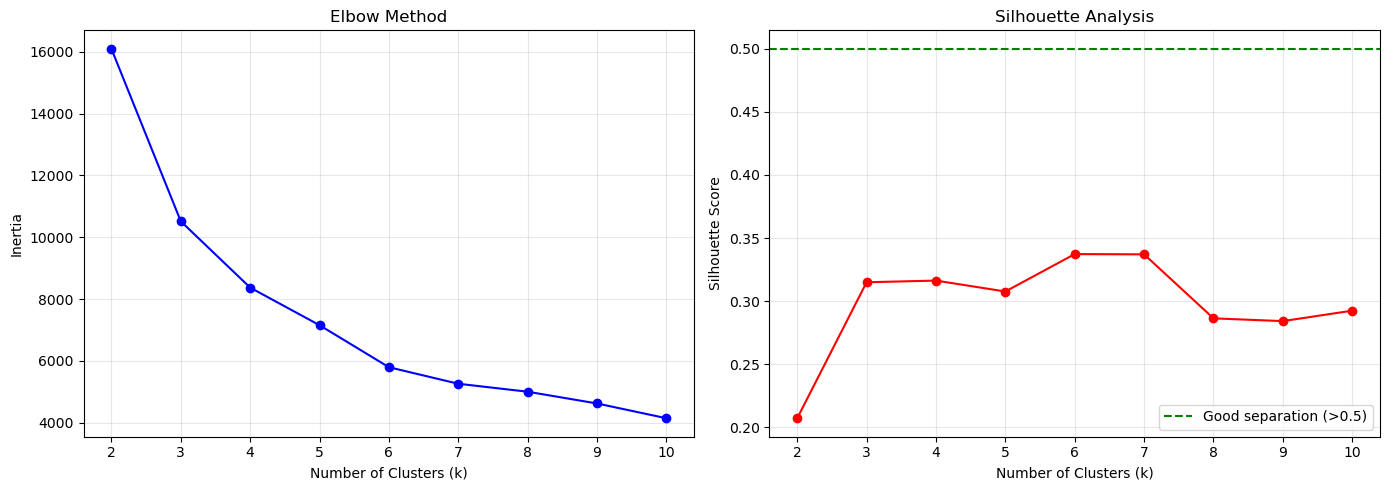


Recommended k: 6 (silhouette score: 0.337)

✓ Recommended k (highest silhouette): 6
  Silhouette score: 0.337

Clustering with k=6...
Silhouette Score: 0.337

Cluster distribution:
  Cluster 0: 92 images (16.3%)
  Cluster 1: 115 images (20.3%)
  Cluster 2: 132 images (23.3%)
  Cluster 3: 86 images (15.2%)
  Cluster 4: 53 images (9.4%)
  Cluster 5: 88 images (15.5%)

Cluster quality metrics:
  Silhouette Score: 0.337 (higher is better, range: [-1, 1])
  Davies-Bouldin Index: 1.026 (lower is better)
  Calinski-Harabasz Score: 283.2 (higher is better)

Visualizing Embeddings in 2D

Generating UMAP projection...
Reducing 256D embeddings to 2D using UMAP...


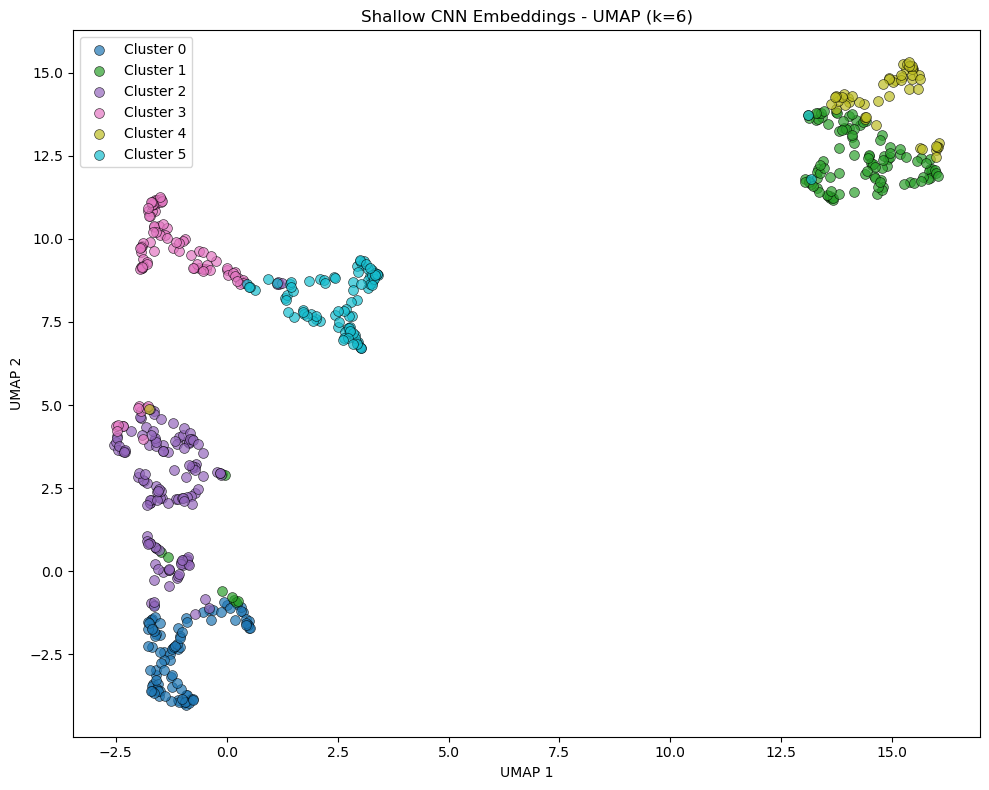


Generating t-SNE projection...
Reducing 256D embeddings to 2D using TSNE...


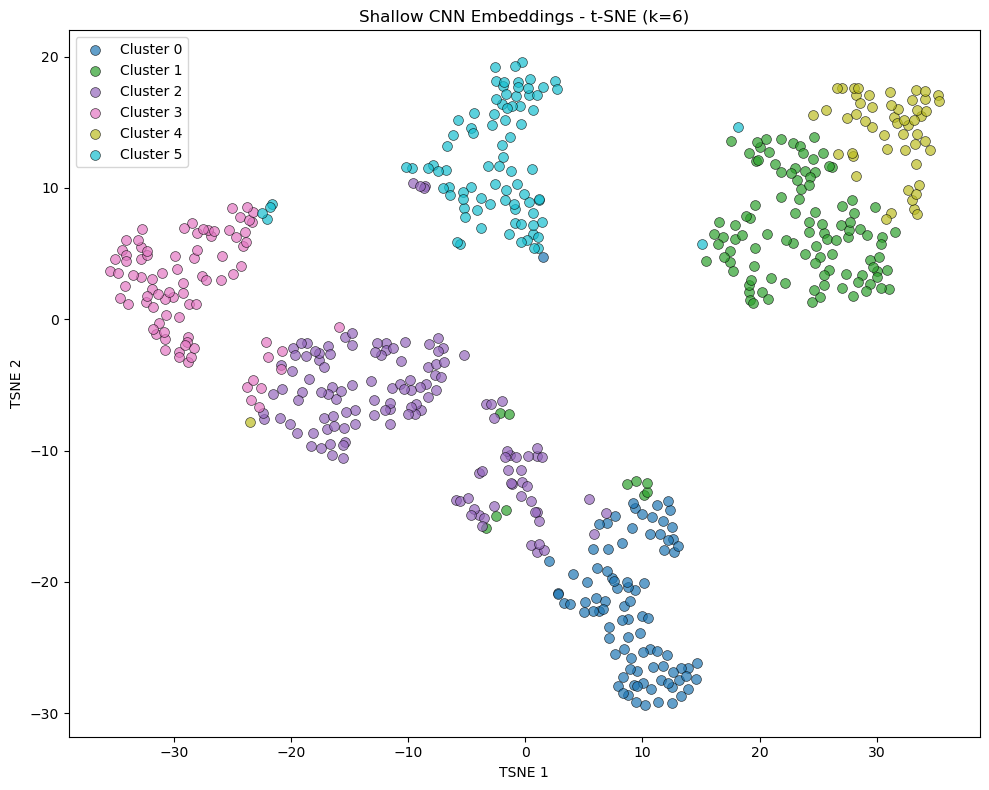


Comparing Different K Values

Clustering with k=3...
Silhouette Score: 0.315

Clustering with k=4...
Silhouette Score: 0.316

Clustering with k=5...
Silhouette Score: 0.308

Clustering with k=6...
Silhouette Score: 0.337


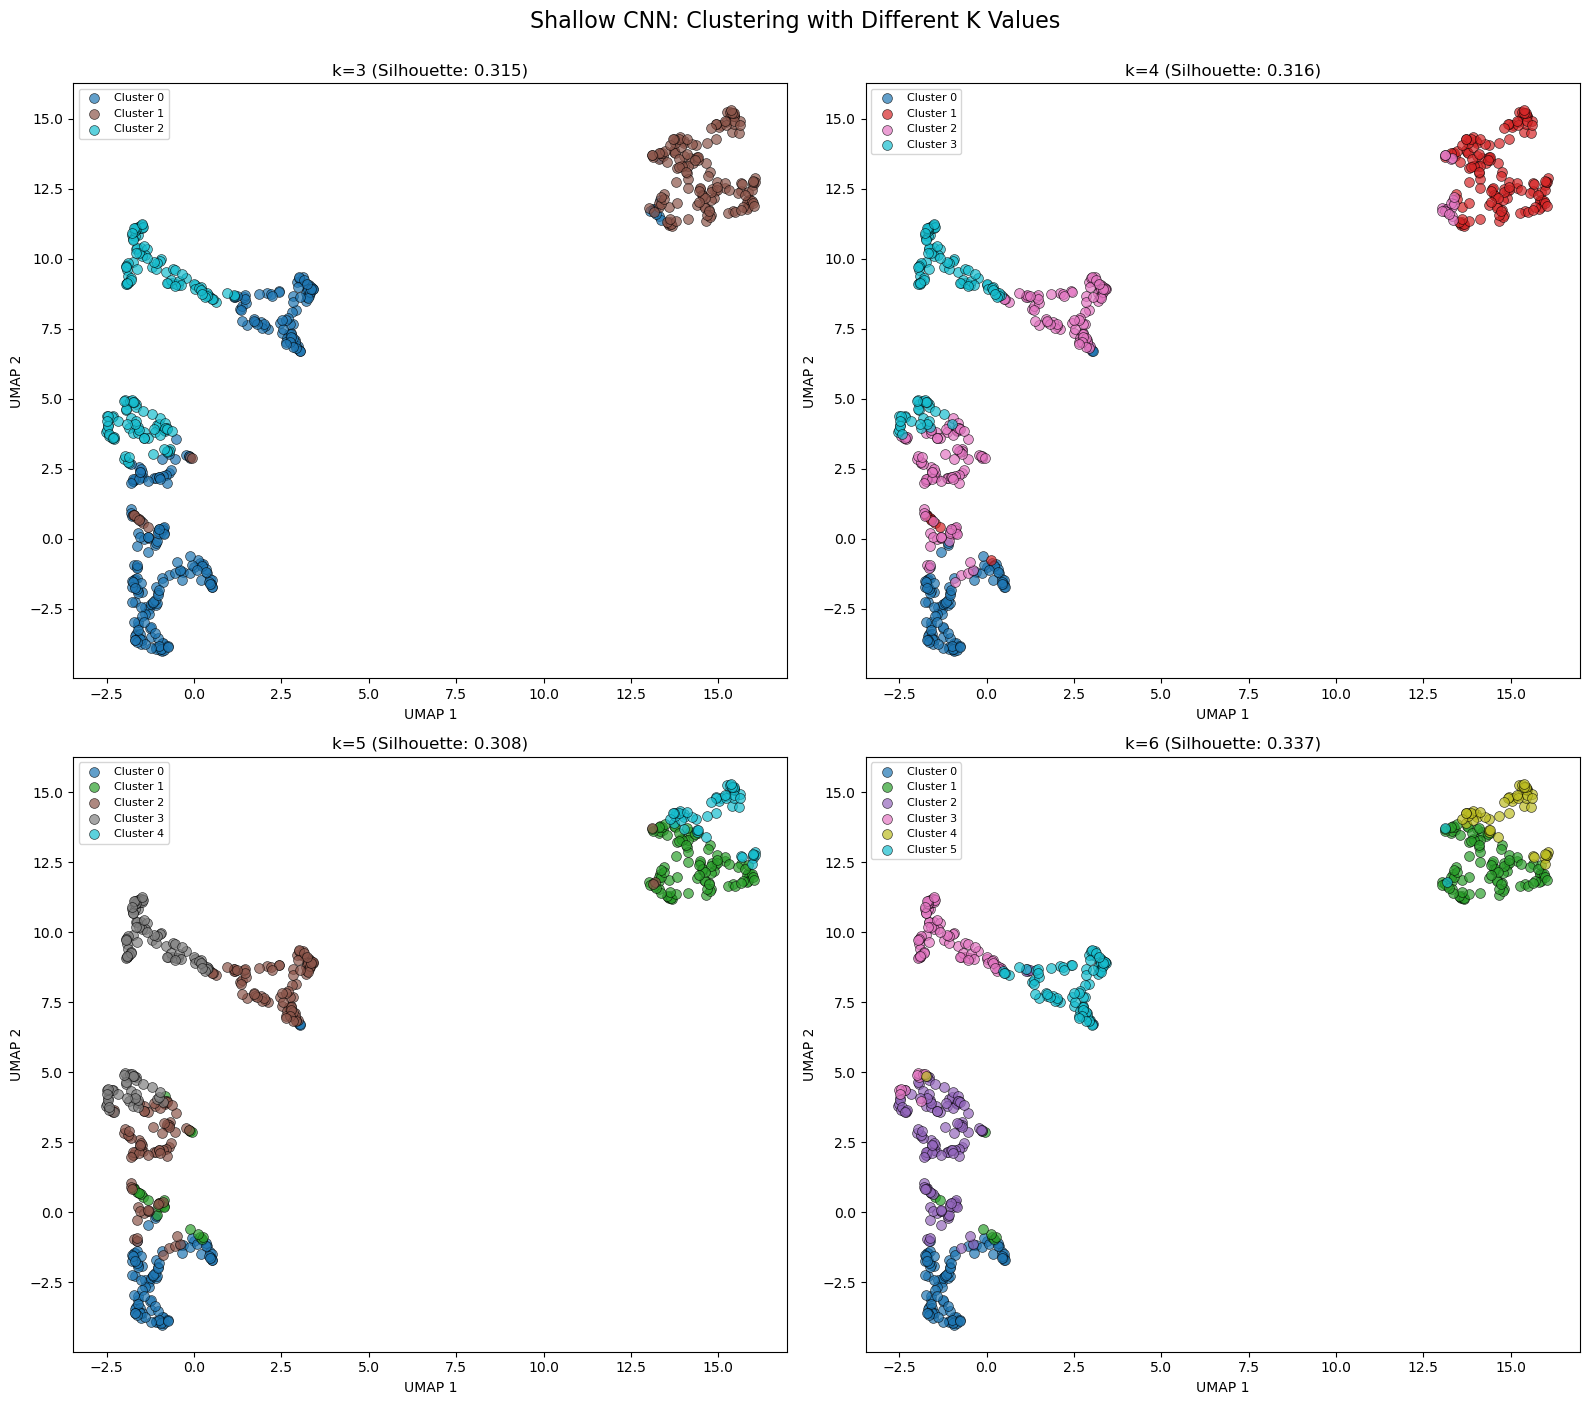


✓ Saved comparison plot: shallow_cnn_comparison_k_values.png

Saving Results
✓ Saved embeddings: shallow_cnn_embeddings.npy
✓ Saved cluster labels: shallow_cnn_cluster_labels.npy
✓ Saved 2D projections
✓ Saved model weights: shallow_cnn_weights.pth

✓ SHALLOW CNN CLUSTERING PIPELINE COMPLETE!

Summary:
  - Embeddings extracted: (566, 256)
  - Optimal clusters found: 6
  - Silhouette score: 0.337
  - Visualizations saved: UMAP, t-SNE, k-comparison


In [39]:
# Find optimal number of clusters
print("\nFinding optimal number of clusters...")
results_shallow = find_optimal_clusters(
    embeddings_shallow,
    max_k=10,
    method='kmeans'
)

# Plot cluster quality metrics (elbow curve + silhouette scores)
plot_cluster_quality(results_shallow)

# Identify optimal k (highest silhouette score)
best_k_idx = np.argmax(results_shallow['silhouette_scores'])
k_optimal_shallow = results_shallow['k_values'][best_k_idx]
print(f"\n✓ Recommended k (highest silhouette): {k_optimal_shallow}")
print(f"  Silhouette score: {results_shallow['silhouette_scores'][best_k_idx]:.3f}")

# Perform clustering with optimal k
print(f"\nClustering with k={k_optimal_shallow}...")
cluster_labels_shallow, cluster_model_shallow = cluster_embeddings(
    embeddings_shallow,
    method='kmeans',
    n_clusters=k_optimal_shallow
)

# Analyze cluster distribution
print("\nCluster distribution:")
unique, counts = np.unique(cluster_labels_shallow, return_counts=True)
for cluster_id, count in zip(unique, counts):
    percentage = 100 * count / len(cluster_labels_shallow)
    print(f"  Cluster {cluster_id}: {count} images ({percentage:.1f}%)")

# Calculate comprehensive cluster quality metrics
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

sil_score = silhouette_score(embeddings_shallow, cluster_labels_shallow)
db_score = davies_bouldin_score(embeddings_shallow, cluster_labels_shallow)
ch_score = calinski_harabasz_score(embeddings_shallow, cluster_labels_shallow)

print("\nCluster quality metrics:")
print(f"  Silhouette Score: {sil_score:.3f} (higher is better, range: [-1, 1])")
print(f"  Davies-Bouldin Index: {db_score:.3f} (lower is better)")
print(f"  Calinski-Harabasz Score: {ch_score:.1f} (higher is better)")


# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*60)
print("Visualizing Embeddings in 2D")
print("="*60)

# UMAP visualization
print("\nGenerating UMAP projection...")
embedding_2d_umap_shallow = visualize_embeddings_2d(
    embeddings_shallow,
    labels=cluster_labels_shallow,
    method='umap',
    title=f'Shallow CNN Embeddings - UMAP (k={k_optimal_shallow})'
)

# t-SNE visualization
print("\nGenerating t-SNE projection...")
embedding_2d_tsne_shallow = visualize_embeddings_2d(
    embeddings_shallow,
    labels=cluster_labels_shallow,
    method='tsne',
    title=f'Shallow CNN Embeddings - t-SNE (k={k_optimal_shallow})'
)


# ============================================================================
# COMPARE MULTIPLE K VALUES
# ============================================================================
print("\n" + "="*60)
print("Comparing Different K Values")
print("="*60)

# Try different k values to visualize cluster separation
k_values_to_try = [3, 4, 5, 6]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Compute UMAP once for consistent visualization
reducer_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d_comparison = reducer_umap.fit_transform(embeddings_shallow)

for idx, k in enumerate(k_values_to_try):
    print(f"\nClustering with k={k}...")
    labels_k, _ = cluster_embeddings(
        embeddings_shallow,
        method='kmeans',
        n_clusters=k
    )

    # Plot on subplot
    ax = axes[idx]
    unique_labels = np.unique(labels_k)
    cmap = plt.cm.get_cmap('tab10', len(unique_labels))

    for i, label in enumerate(unique_labels):
        mask = labels_k == label
        ax.scatter(embedding_2d_comparison[mask, 0], embedding_2d_comparison[mask, 1],
                  c=[cmap(i)], label=f'Cluster {label}',
                  alpha=0.7, s=50, edgecolors='black', linewidth=0.5)

    sil = silhouette_score(embeddings_shallow, labels_k)
    ax.set_title(f'k={k} (Silhouette: {sil:.3f})', fontsize=12)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(loc='best', fontsize=8)

plt.suptitle('Shallow CNN: Clustering with Different K Values', fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig('shallow_cnn_comparison_k_values.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved comparison plot: shallow_cnn_comparison_k_values.png")


# ============================================================================
# SAVE RESULTS
# ============================================================================
print("\n" + "="*60)
print("Saving Results")
print("="*60)

# Save embeddings
np.save('shallow_cnn_embeddings.npy', embeddings_shallow)
print(f"✓ Saved embeddings: shallow_cnn_embeddings.npy")

# Save cluster labels
np.save('shallow_cnn_cluster_labels.npy', cluster_labels_shallow)
print(f"✓ Saved cluster labels: shallow_cnn_cluster_labels.npy")

# Save 2D projections
np.save('shallow_cnn_umap_2d.npy', embedding_2d_umap_shallow)
np.save('shallow_cnn_tsne_2d.npy', embedding_2d_tsne_shallow)
print(f"✓ Saved 2D projections")

# Save model weights
torch.save(shallow_model.state_dict(), 'shallow_cnn_weights.pth')
print(f"✓ Saved model weights: shallow_cnn_weights.pth")

print("\n" + "="*60)
print("✓ SHALLOW CNN CLUSTERING PIPELINE COMPLETE!")
print("="*60)
print(f"\nSummary:")
print(f"  - Embeddings extracted: {embeddings_shallow.shape}")
print(f"  - Optimal clusters found: {k_optimal_shallow}")
print(f"  - Silhouette score: {sil_score:.3f}")
print(f"  - Visualizations saved: UMAP, t-SNE, k-comparison")


## Interpreting Shallow CNN Results

Creating 2D UMAP projection...


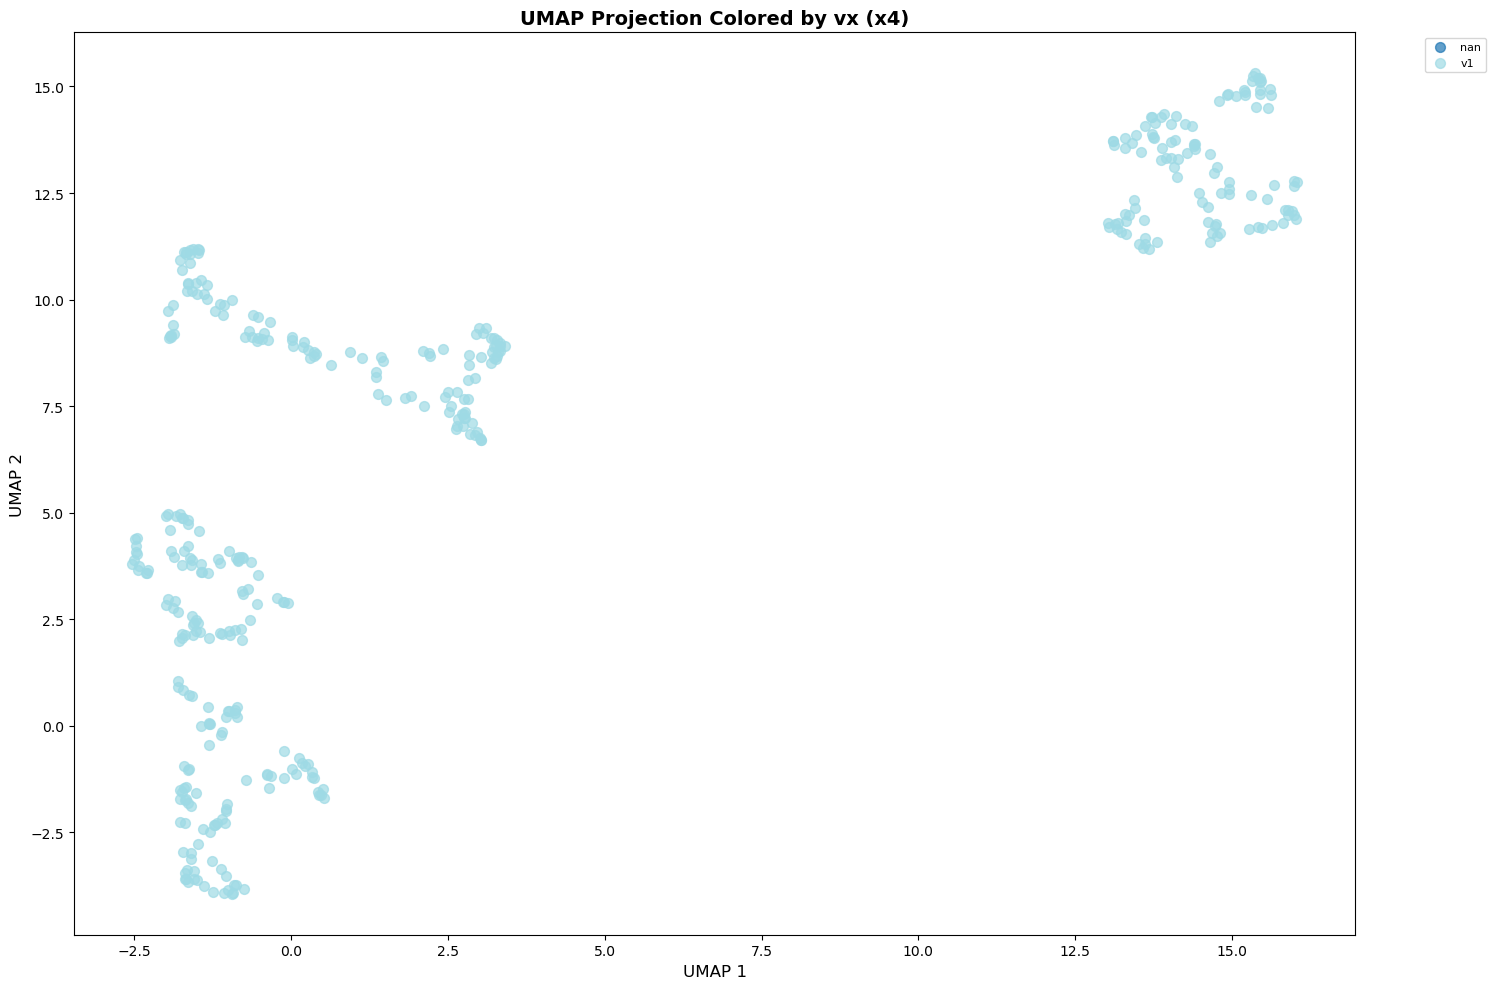

In [59]:
# Example usage:
# ============================================================================
# After extracting embeddings and clustering, run:
#
metadata_path = "/Users/leahashebir/Downloads/Manor_Practicum/liberman_data/WPZ Mouse groups.xlsx"
#
# # Merge everything
results_df = merge_clusters_with_metadata(
    embeddings=embeddings_shallow,
    cluster_labels=cluster_labels_shallow,
    image_paths=image_paths,
    experimental_metadata=final_clean_strained_grouped_pos_cleangroup_vs_timed_strain_encoded
)
#
# # Visualize by different attributes
# coords = visualize_clusters_by_metadata(embeddings_shallow, results_df, color_by='cluster')
# coords = visualize_clusters_by_metadata(embeddings_shallow, results_df, color_by='Group')
# coords = visualize_clusters_by_metadata(embeddings_shallow, results_df, color_by='Group - dB (x6)')
# coords = visualize_clusters_by_metadata(embeddings_shallow, results_df, color_by='Group - Time Elapsed')
# coords = visualize_clusters_by_metadata(embeddings_shallow, results_df, color_by='Strain (x5)')
# coords = visualize_clusters_by_metadata(embeddings_shallow, results_df, color_by='Freq(kHz) (x1))')
coords = visualize_clusters_by_metadata(embeddings_shallow, results_df, color_by='vx (x4)')

In [ ]:
# Analyze composition
composition = analyze_cluster_composition(results_df, groupby_cols=['Group', 'Strain', 'frequency'])
# ============================================================================


Cluster Composition by Group

Counts:
Group    14wks ctrl  6wks ctrl  8wks ctrl  90dB 0h post  94dB 0h post  \
cluster                                                                 
0                15          9          5             1            12   
1                81         23         17            15            36   

Group    94dB 24h post  94dB 2w post  94dB 8wks post  98dB 0h post  \
cluster                                                              
0                    7             3               9             3   
1                   25            29              39            13   

Group    98dB 24h post  98dB 2w post  98dB 8wks post  
cluster                                               
0                   19            11              19  
1                   61            37              77  

Percentages:
Group    14wks ctrl  6wks ctrl  8wks ctrl  90dB 0h post  94dB 0h post  \
cluster                                                                 
0      

In [ ]:
# pd.DataFrame(composition)
results_df

,subject,frequency,view,file_path,filename,Group,Strain,cluster,emb_dim_0,emb_dim_1,emb_dim_2,emb_dim_3,emb_dim_4,emb_dim_5,emb_dim_6,emb_dim_7,emb_dim_8,emb_dim_9
0,WPZ145,5.6,v1,/Users/leahashebir/Downloads/Manor_Practicum/l...,WPZ145L.CtBP2.GluR2.NF.Myo7.IHC.5.6.v1.lif,98dB 8wks post,C57B6,1,-0.510242,-0.493767,-0.014572,-0.480756,0.108221,0.090302,-0.161624,-0.258900,0.548549,0.191912
1,WPZ145,11.3,v1,/Users/leahashebir/Downloads/Manor_Practicum/l...,WPZ145L.CtBP2.GluR2.NF.Myo7.IHC.11.3.v1.lif,98dB 8wks post,C57B6,1,-0.260076,0.199292,0.286450,-0.538163,0.109451,0.083443,-0.020632,-0.118294,0.406096,-0.047137
2,WPZ145,64.0,v2,/Users/leahashebir/Downloads/Manor_Practicum/l...,WPZ145L.CtBP2.GluR2.NF.Myo7.IHC.64.0.v2.lif,98dB 8wks post,C57B6,1,0.123452,0.291358,0.436767,-0.046479,-0.103427,0.112089,0.363927,0.390297,0.652806,0.010992
3,WPZ145,5.6,v2,/Users/leahashebir/Downloads/Manor_Practicum/l...,WPZ145L.CtBP2.GluR2.NF.Myo7.IHC.5.6.v2.lif,98dB 8wks post,C57B6,1,-0.096634,0.661787,0.325383,-0.450333,-0.032588,-0.533764,0.038028,0.252188,0.384771,-0.221042
4,WPZ145,11.3,v2,/Users/leahashebir/Downloads/Manor_Practicum/l...,WPZ145L.CtBP2.GluR2.NF.Myo7.IHC.11.3.v2.lif,98dB 8wks post,C57B6,0,-1.400173,-0.669614,-0.315134,-0.332319,0.856810,0.544659,-0.764917,-0.966208,0.472011,-0.134493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561,WPZ101,32.0,v2,/Users/leahashebir/Downloads/Manor_Practicum/l...,WPZ101L.CtBP2.GluR2.NF.Myo7.IHC.32.0.v2.lif,8wks ctrl,C57B6,1,0.138265,0.357917,0.396106,-0.014037,-0.064445,0.133999,0.255888,0.229710,0.643319,-0.116552
562,WPZ101,45.2,v2,/Users/leahashebir/Downloads/Manor_Practicum/l...,WPZ101L.CtBP2.GluR2.NF.Myo7.IHC.45.2.v2.lif,8wks ctrl,C57B6,1,0.275575,0.477567,0.282032,0.314213,-0.124626,0.157649,0.190546,0.309743,0.932517,-0.184768
563,WPZ101,45.2,v1,/Users/leahashebir/Downloads/Manor_Practicum/l...,WPZ101L.CtBP2.GluR2.NF.Myo7.IHC.45.2.v1.lif,8wks ctrl,C57B6,1,0.042842,0.714217,0.395259,-0.465802,-0.015234,-0.552011,0.188896,0.292479,0.428704,-0.291019
564,WPZ101,64.0,v1,/Users/leahashebir/Downloads/Manor_Practicum/l...,WPZ101L.CtBP2.GluR2.NF.Myo7.IHC.64.0.v1.lif,8wks ctrl,C57B6,1,-0.465887,-0.515317,-0.208907,-0.513907,0.279337,0.236894,-0.332662,-0.277902,0.736698,0.339709


In [ ]:
clusters=results_df[['file_path', 'cluster']]

## Fine Tuning

In [ ]:
# from typing import Any

# class ShallowCNN_Tuning(nn.Module):
#     """
#     Lightweight 3-layer CNN for quick signal validation.
    
#     Purpose: Fast check if images contain learnable morphological patterns
#     Training time: ~5-10 minutes
    
#     Architecture:
#         Input: 4-channel 224x224 images
#         Conv1: 4 → 32 channels (3x3)
#         Conv2: 32 → 64 channels (3x3)
#         Conv3: 64 → 128 channels (3x3)
#         Global pooling → 256-dim embedding
#     """
#     def __init__(self, input_channels=4, embedding_dim=256, learning_rate=0.001, temperature=0.3, batch_size=4, num_workers=0):
#         super(ShallowCNN_Tuning, self).__init__()
#         # Itemizing train loader parameters
#         self.batch_size = batch_size
#         self.num_workers = num_workers

#         # Train loader
#         self.train_loader = create_dataloader(
#             image_paths, 
#             batch_size=batch_size,  
#             shuffle=True,
#             augment=True,  # Set True for Shallow CNN contrastive learning
#             num_workers=self.num_workers,  # Increase if using multiple CPU cores
#         )
        
#         # Itemizing model tuning parameters
#         self.learning_rate = learning_rate
#         self.embedding_dim = embedding_dim
#         self.temperature = temperature
        
#         # Conv blocks
#         self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
#         self.bn1 = nn.BatchNorm2d(32)
#         self.pool1 = nn.AvgPool2d(2, 2)  # 224 → 112 , NOT REDUNDANT because we are max pooling in XY not Z
        
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
#         self.bn2 = nn.BatchNorm2d(64)
#         self.pool2 = nn.AvgPool2d(2, 2)  # 112 → 56
        
#         self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
#         self.bn3 = nn.BatchNorm2d(128)
#         self.pool3 = nn.AvgPool2d(2, 2)  # 56 → 28
        
#         self.gap = nn.AdaptiveAvgPool2d(1)  # 28x28x128 → 1x1x128
#         self.fc = nn.Linear(128, embedding_dim)
        
#     def forward(self, x):
#         # x: [batch, 4, 224, 224]
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = self.pool1(x)
        
#         x = F.relu(self.bn2(self.conv2(x)))
#         x = self.pool2(x)
        
#         x = F.relu(self.bn3(self.conv3(x)))
#         x = self.pool3(x)
        
#         x = self.gap(x)  # [batch, 128, 1, 1]
#         x = x.view(x.size(0), -1)  # [batch, 128]
#         x = self.fc(x)  # [batch, embedding_dim]
        
#         return x


#     def contrastive_loss(self, emb1, emb2, temperature=self.temperature):
#         """
#         Proper contrastive loss (NT-Xent / SimCLR style).
        
#         Args:
#             emb1, emb2: Embeddings from original and paired images
#             temperature: Temperature parameter (typically 0.3)
        
#         Returns:
#             Scalar loss value
#         """
#         batch_size = emb1.shape[0]
        
#         # L2 normalize (makes it cosine similarity instead of dot product)
#         emb1 = F.normalize(emb1, dim=1)
#         emb2 = F.normalize(emb2, dim=1)
        

#         embeddings = torch.cat([emb1, emb2], dim=0)  # [2*batch, dim]
        

#         similarity = torch.mm(embeddings, embeddings.T) / temperature  # [2*batch, 2*batch]
        

#         labels = torch.cat([torch.arange(batch_size) + batch_size,  # emb1 → emb2
#                             torch.arange(batch_size)], dim=0)       # emb2 → emb1
#         labels = labels.to(emb1.device)
        

#         mask = torch.eye(2*batch_size, dtype=torch.bool, device=emb1.device)
#         similarity = similarity.masked_fill(mask, -1e9)
        
#         # Cross-entropy loss (treats as classification problem)
#         loss = F.cross_entropy(similarity, labels)
        
#         return loss


#     def train_shallow_cnn_contrastive(self, model, dataset, temperature=self.temperature, batch_size=self.batch_size, 
#                                     epochs=10, lr=self.learning_rate, device='mps'):
#         """
#         Train with v1/v2 pairing from filenames.
#         For each image in batch, loads its pair on-demand.
#         """

#         model = model.to(device)
        
#         projection_head = nn.Sequential(
#             nn.Linear(256, 256),
#             nn.ReLU(),
#             nn.Linear(256, 128)
#         ).to(device)
        
#         # FIXED: Optimize both
#         optimizer = torch.optim.Adam(
#             list(model.parameters()) + list(projection_head.parameters()), 
#             lr=lr
#         )
        
#         model.train()
#         projection_head.train()
#         losses = []
        
#         for epoch in range(epochs):
#             total_loss = 0
#             num_batches = len(dataset) // batch_size
#             valid_batches = 0
            
#             for batch_idx in range(num_batches):
#                 # Sample random indices
#                 indices = torch.randperm(len(dataset))[:batch_size]
                
#                 original_image_list = []
#                 paired_image_list = []
                
#                 # For each image, get its pair
#                 for idx in indices:
#                     img, pair_img = dataset.get_pair(idx.item())
                    
#                     # Skip if original image failed to load
#                     if img is None:
#                         continue
                    
#                     # Skip if pair doesn't exist or failed to load
#                     if pair_img is not None:
#                         original_image_list.append(img)
#                         paired_image_list.append(pair_img)
                
#                 # Skip batch if too few pairs found
#                 if len(paired_image_list) < 2:
#                     continue
                
#                 original_image_batch = torch.stack(original_image_list).to(device)
#                 paired_image_batch = torch.stack(paired_image_list).to(device)
                
#                 # Forward pass
#                 emb1 = model(original_image_batch)
#                 emb2 = model(paired_image_batch)
                
#                 proj1 = projection_head(emb1)
#                 proj2 = projection_head(emb2)
                
#                 # Contrastive loss
#                 loss = contrastive_loss(proj1, proj2, temperature=temperature)
                
#                 optimizer.zero_grad()
#                 loss.backward()
#                 optimizer.step()
                
#                 total_loss += loss.item()
#                 valid_batches += 1
            
#             avg_loss = total_loss / valid_batches if valid_batches > 0 else 0
#             losses.append(avg_loss)
#             print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Valid batches: {valid_batches}")
        
#         return losses, model


In [ ]:
class ShallowCNN_Tuning:
    """
    Factory class for building ShallowCNN model + dataloader with hyperparameter tuning.
    
    Usage:
        builder = ShallowCNN_Tuning(
            image_paths=lif_paths,
            embedding_dim=256,
            learning_rate=0.001,
            temperature=0.3,
            batch_size=4
        )
        model, dataloader = builder.build()
        losses, trained_model = builder.train(model, dataloader, epochs=10)
    """
    def __init__(self, image_paths, input_channels=4, embedding_dim=256, 
                 learning_rate=0.001, temperature=0.3, batch_size=4, 
                 num_workers=0, optimizer='Adam', target_size=224):
        # Store hyperparameters
        self.image_paths = image_paths
        self.input_channels = input_channels
        self.embedding_dim = embedding_dim
        self.learning_rate = learning_rate
        self.temperature = temperature
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.target_size = target_size  
        self.optimizer = optimizer
    
    def build(self, device='mps'):
        """
        Build and return model + dataloader.
        
        Returns:
            model: ShallowCNN instance
            dataloader: DataLoader instance
        """
        # Build model
        model = ShallowCNN(
            input_channels=self.input_channels,
            embedding_dim=self.embedding_dim
        )
        
        dataloader = DataLoader(
            image_paths,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True if torch.cuda.is_available() else False
        )
        
        return model, dataloader

    def build(self, device='mps'):
        """
        Build and return model + dataset + dataloader.
        
        Returns:
            model: ShallowCNN instance
            paired_dataset: PairedSynapseDataset for training
            eval_dataloader: DataLoader for embedding extraction
        """
        # Build model
        model = ShallowCNN(
            input_channels=self.input_channels,
            embedding_dim=self.embedding_dim
        )
        
        # Build paired dataset for training (has .get_pair() method)
        paired_dataset = PairedSynapseDataset(
            image_paths=self.image_paths,
            target_size=self.target_size
        )
        
        # Build simple dataset for evaluation/embedding extraction
        eval_dataset = SynapseImageDataset(
            image_paths=self.image_paths,
            augment=False,
            target_size=self.target_size
        )
        
        # Create dataloader for embedding extraction
        eval_dataloader = DataLoader(
            eval_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True if torch.cuda.is_available() else False
        )
        
        return model, paired_dataset, eval_dataloader
    
    def train(self, model, dataset, epochs=10, device='mps'):
        """
        Train the model with contrastive learning.
        
        Args:
            model: ShallowCNN instance
            dataset: PairedSynapseDataset instance
            epochs: Number of training epochs
            device: Device to train on
        
        Returns:
            losses: List of average losses per epoch
            model: Trained encoder (without projection head)
        """
        model = model.to(device)
        
        # Create projection head
        projection_head = nn.Sequential(
            nn.Linear(self.embedding_dim, self.embedding_dim),
            nn.ReLU(),
            nn.Linear(self.embedding_dim, 128)
        ).to(device)
        
        # Optimizer for both model and projection head
        if self.optimizer == 'Adam':
            optimizer = torch.optim.Adam(
                list(model.parameters()) + list(projection_head.parameters()),
                lr=self.learning_rate
            )
        elif self.optimizer == 'SGD':
            optimizer = torch.optim.SGD(
                list(model.parameters()) + list(projection_head.parameters()),
                lr=self.learning_rate
            )

        model.train()
        projection_head.train()
        losses = []
        
        for epoch in range(epochs):
            total_loss = 0
            num_batches = len(dataset) // self.batch_size
            valid_batches = 0
            
            for batch_idx in range(num_batches):
                # Sample random indices
                indices = torch.randperm(len(dataset))[:self.batch_size]
                
                original_image_list = []
                paired_image_list = []
                
                # For each image, get its pair
                for idx in indices:
                    img, pair_img = dataset.get_pair(idx.item())
                    
                    if img is not None and pair_img is not None:
                        original_image_list.append(img)
                        paired_image_list.append(pair_img)
                
                # Skip batch if too few pairs found
                if len(paired_image_list) < 2:
                    continue
                
                original_image_batch = torch.stack(original_image_list).to(device)
                paired_image_batch = torch.stack(paired_image_list).to(device)
                
                # Forward pass through encoder
                emb1 = model(original_image_batch)
                emb2 = model(paired_image_batch)
                
                # Forward pass through projection head
                proj1 = projection_head(emb1)
                proj2 = projection_head(emb2)
                
                # Compute contrastive loss
                loss = self._contrastive_loss(proj1, proj2)
                
                # Backward pass
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                total_loss += loss.item()
                valid_batches += 1
            
            avg_loss = total_loss / valid_batches if valid_batches > 0 else 0
            losses.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Valid batches: {valid_batches}")
        
        return losses, model  # Return encoder only, not projection head
    
    def _contrastive_loss(self, emb1, emb2):
        """
        Contrastive loss (NT-Xent / SimCLR style).
        
        Args:
            emb1, emb2: Embeddings from original and paired images [batch_size, embedding_dim]
        
        Returns:
            Scalar loss value
        """
        batch_size = emb1.shape[0]
        
        # L2 normalize
        emb1 = F.normalize(emb1, dim=1)
        emb2 = F.normalize(emb2, dim=1)
        
        # Concatenate
        embeddings = torch.cat([emb1, emb2], dim=0)  # [2*batch, dim]
        
        # Compute similarity matrix
        similarity = torch.mm(embeddings, embeddings.T) / self.temperature
        
        # Create labels
        labels = torch.cat([
            torch.arange(batch_size) + batch_size,  # emb1 → emb2
            torch.arange(batch_size)                # emb2 → emb1
        ], dim=0).to(emb1.device)
        
        # Mask diagonal
        mask = torch.eye(2*batch_size, dtype=torch.bool, device=emb1.device)
        similarity = similarity.masked_fill(mask, -1e9)
        
        # Cross-entropy loss
        loss = F.cross_entropy(similarity, labels)
        
        return loss


# Keep ShallowCNN as a clean model architecture (no training logic inside)
class ShallowCNN(nn.Module):
    """
    Lightweight 3-layer CNN encoder.
    
    Architecture:
        Input: 4-channel 224x224 images
        Conv1: 4 → 32 channels (3x3)
        Conv2: 32 → 64 channels (3x3)
        Conv3: 64 → 128 channels (3x3)
        Global pooling → embedding_dim output
    """
    def __init__(self, input_channels=4, embedding_dim=256):
        super(ShallowCNN, self).__init__()
        
        # Conv blocks with AvgPool
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.AvgPool2d(2, 2)  # 224 → 112
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.AvgPool2d(2, 2)  # 112 → 56
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.AvgPool2d(2, 2)  # 56 → 28
        
        self.gap = nn.AdaptiveAvgPool2d(1)  # 28x28x128 → 1x1x128
        self.fc = nn.Linear(128, embedding_dim)
        
    def forward(self, x):
        # x: [batch, 4, 224, 224]
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        
        x = self.gap(x)  # [batch, 128, 1, 1]
        x = x.view(x.size(0), -1)  # [batch, 128]
        x = self.fc(x)  # [batch, embedding_dim]
        
        return x

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

# INCORPORATE IN THE MLFLOW WORKFLOW

learning_rates = [0.001, 0.01, 0.1, 1]
temperatures = [0.1, 0.2, 0.3]
results = {}
best_db = 0
best_config = None
count = 0

for learning_rate in learning_rates:
    for temperature in temperatures:
        count += 1
        print("\n" + "="*60)
        print(f"Model {count}: Learning rate: {learning_rate}, Temperature: {temperature}")
        print("="*60)

        # Model Training
        # shallow_model, dataloader = ShallowCNN_Tuning(input_channels=4, embedding_dim=256, learning_rate=learning_rate, temperature=temperature, batch_size=4, num_workers=0)
        builder = ShallowCNN_Tuning(
            image_paths=image_paths,
            embedding_dim=256,
            learning_rate=learning_rate,
            temperature=temperature,
            batch_size=4
        )
        
        model, paired_dataset, eval_dataloader = builder.build()
        losses, trained_model = builder.train(model, paired_dataset, epochs=10, device='mps')
        embeddings_shallow = extract_embeddings_shallow(trained_model, eval_dataloader, device='mps')
        
        results_shallow = find_optimal_clusters(embeddings_shallow, max_k=10, method='kmeans')
        plot_cluster_quality(results_shallow)
        best_k_idx = np.argmax(results_shallow['silhouette_scores'])
        k_optimal_shallow = results_shallow['k_values'][best_k_idx]
        sil_score = results_shallow['silhouette_scores'][best_k_idx]
        cluster_labels_shallow, cluster_model_shallow = cluster_embeddings(embeddings_shallow, method='kmeans', n_clusters=k_optimal_shallow)
        db_score = davies_bouldin_score(embeddings_shallow, cluster_labels_shallow)
        if db_score > best_db:
            best_db = db_score
            best_config = (learning_rate, temperature)

        results[f'Model {count}'] = {
            'learning_rate': learning_rate,
            'temperature': temperature,
            'final_loss': losses[-1],
            'best_k': k_optimal_shallow,
            'silhouette_score': sil_score,
            'db_score': db_score,
            'losses': losses,
            'model': model,
            'train_loader_aug': train_loader_aug
        }
        plot_training_curves(losses, model_name=f'Shallow CNN - Model {count}')
        print(f"Model data saved successfully. Model parameters: {sum(p.numel() for p in shallow_model.parameters()):,}. Silhouette Score for best k={k_optimal_shallow}: {sil_score:.4f}. Davies-Bouldin Score: {db_score:.4f}.")

print(f'Best Shallow CNN Config Based on Davies-Bouldin Score: {best_config}')

In [ ]:
# batch_sizes = [4, 8]
# latent_dims = [128, 256, 512, 1024]
# optimizers = ['Adam', 'SGD'] NEED TO UPDATE THE MODEL TO MAKE THIS AN INPUT

# II. Convolutional Autoencoder Embedder

Once signal has been confirmed, using a more advanced model for smarter clustering

ALERT ALERT, must set augment to FALSE here

In [ ]:
class ConvAutoencoder(nn.Module):
    """
    Symmetric convolutional autoencoder for unsupervised embedding learning.
    
    Better than Shallow CNN because:
    - Reconstruction objective forces meaningful representations
    - Deeper architecture learns hierarchical features
    - Bottleneck naturally creates compressed embeddings
    
    Architecture:
        Encoder: 4 conv blocks → 512-dim bottleneck
        Decoder: 4 transpose conv blocks → reconstruct 4 channels
        Loss: Contrastive loss
    """
    def __init__(self, input_channels=4, latent_dim=512):
        super(ConvAutoencoder, self).__init__()
        
        # ENCODER
        # 224x224x4 → 112x112x32
        self.enc1 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
        # 112x112x32 → 56x56x64
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # 56x56x64 → 28x28x128
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        # 28x28x128 → 14x14x256
        self.enc4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        
        # Flatten and bottleneck
        self.flatten = nn.Flatten()
        self.fc_enc = nn.Linear(256 * 14 * 14, latent_dim)
        
        # DECODER
        self.fc_dec = nn.Linear(latent_dim, 256 * 14 * 14)
        
        # 14x14x256 → 28x28x128
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        # 28x28x128 → 56x56x64
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # 56x56x64 → 112x112x32
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
        # 112x112x32 → 224x224x4
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(32, input_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0,1] range
        )
        
        self.latent_dim = latent_dim
    
    def encode(self, x):
        """Extract embedding from image"""
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.enc4(x)
        x = self.flatten(x)
        z = self.fc_enc(x)
        return z
    
    def decode(self, z):
        """Reconstruct image from embedding"""
        x = self.fc_dec(z)
        x = x.view(-1, 256, 14, 14)
        x = self.dec1(x)
        x = self.dec2(x)
        x = self.dec3(x)
        x = self.dec4(x)
        return x
    
    def forward(self, x):
        """Full forward pass: encode → decode"""
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z


# def train_conv_autoencoder(model, dataloader, epochs=20, lr=1e-3, device='cpu'):
#     """
#     Train Convolutional Autoencoder with MSE reconstruction loss.
#     """
#     model = model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()
    
#     model.train()
#     losses = []
    
#     for epoch in range(epochs):
#         epoch_loss = 0
#         for batch_idx, batch in enumerate(dataloader):
#             # Handle paired data or single images
#             if isinstance(batch, (list, tuple)):
#                 images = batch[0]
#             else:
#                 images = batch
            
#             images = images.to(device)
            
#             # Forward pass
#             reconstructions, embeddings = model(images)
            
#             # Reconstruction loss
#             loss = criterion(reconstructions, images)
            
#             # Backward pass
#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()
            
#             epoch_loss += loss.item()
        
#         avg_loss = epoch_loss / len(dataloader)
#         losses.append(avg_loss)
#         print(f"Epoch {epoch+1}/{epochs}, Reconstruction Loss: {avg_loss:.6f}")
    
#     return losses


def extract_embeddings_autoencoder(model, dataloader, device='cpu'):
    """Extract embeddings from trained autoencoder"""
    model = model.to(device)
    model.eval()
    
    embeddings = []
    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                batch = batch[0]
            batch = batch.to(device)
            z = model.encode(batch)
            embeddings.append(z.cpu().numpy())
    
    return np.vstack(embeddings)

# III. Variantional Autoencoder Embedder

In [27]:
train_loader = create_dataloader(
    image_paths, 
    batch_size=4,  # Adjust based on your GPU memory
    shuffle=True,
    augment=False,  # Set True for Shallow CNN contrastive learning
    num_workers=0,  # Increase if using multiple CPU cores
    target_size=224
)

NameError: name 'transforms' is not defined

In [22]:
class VAE(nn.Module):
    """
    Variational Autoencoder - BEST for unsupervised clustering.
    
    Why VAE is superior for this task:
    1. Structured latent space - regularization forces organization
    2. Natural clustering - similar images cluster together
    3. Probabilistic - captures uncertainty in embeddings
    4. Prevents overfitting - KL divergence acts as regularizer
    5. Interpretable - can sample and interpolate in latent space
    
    Architecture:
        Encoder: Conv layers → mean & log_variance
        Reparameterization: Sample from N(mean, variance)
        Decoder: Reconstruct from sampled latent vector
        Loss: Reconstruction + KL divergence
    """
    def __init__(self, input_channels=4, latent_dim=256):
        super(VAE, self).__init__()
        
        # ENCODER (same as Conv Autoencoder)
        self.enc1 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        self.enc4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        
        self.flatten = nn.Flatten()
        
        # VAE-specific: Output mean and log_variance
        self.fc_mu = nn.Linear(256 * 14 * 14, latent_dim)
        self.fc_logvar = nn.Linear(256 * 14 * 14, latent_dim)
        
        # DECODER
        self.fc_dec = nn.Linear(latent_dim, 256 * 14 * 14)
        
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(32, input_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        
        self.latent_dim = latent_dim
    
    def encode(self, x):
        """Encode to mean and log_variance"""
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.enc4(x)
        x = self.flatten(x)
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: z = mu + epsilon * sigma
        where epsilon ~ N(0, 1)
        
        This allows backpropagation through sampling
        """
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + epsilon * std
        return z
    
    def decode(self, z):
        """Reconstruct image from latent vector"""
        x = self.fc_dec(z)
        x = x.view(-1, 256, 14, 14)
        x = self.dec1(x)
        x = self.dec2(x)
        x = self.dec3(x)
        x = self.dec4(x)
        return x
    
    def forward(self, x):
        """Full VAE forward pass"""
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


def vae_loss_function(recon_x, x, mu, logvar, beta=1.0):
    """
    VAE loss = Reconstruction loss + KL divergence
    
    Args:
        recon_x: Reconstructed images
        x: Original images
        mu: Mean of latent distribution
        logvar: Log variance of latent distribution
        beta: Weight for KL divergence (beta-VAE)
              - beta=1.0: Standard VAE
              - beta>1.0: Stronger regularization (more disentangled representations)
              - beta<1.0: Weaker regularization (better reconstructions)
    
    Returns:
        total_loss, recon_loss, kl_loss
    """
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL divergence: KL(N(mu, sigma) || N(0, 1))
    # = 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Total loss
    total_loss = recon_loss + beta * kl_loss
    
    return total_loss, recon_loss, kl_loss


def train_vae(model, dataloader, epochs=30, lr=1e-3, beta=1.0, device='cpu'):
    """
    Train Variational Autoencoder.
    
    Args:
        beta: KL divergence weight
              - Start with beta=0.5 for easier training
              - Increase to beta=1.0-2.0 for better clustering
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    losses = {'total': [], 'recon': [], 'kl': []}
    
    for epoch in range(epochs):
        epoch_total = 0
        epoch_recon = 0
        epoch_kl = 0
        
        for batch_idx, batch in enumerate(dataloader):
            if isinstance(batch, (list, tuple)):
                images = batch[0]
            else:
                images = batch
            
            images = images.to(device)
            
            # Forward pass
            reconstructions, mu, logvar = model(images)
            
            # Compute loss
            total_loss, recon_loss, kl_loss = vae_loss_function(
                reconstructions, images, mu, logvar, beta=beta
            )
            
            # Backward pass
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            
            # Track losses
            batch_size = images.size(0)
            epoch_total += total_loss.item()
            epoch_recon += recon_loss.item()
            epoch_kl += kl_loss.item()
        
        # Average losses
        num_samples = len(dataloader.dataset)
        avg_total = epoch_total / num_samples
        avg_recon = epoch_recon / num_samples
        avg_kl = epoch_kl / num_samples
        
        losses['total'].append(avg_total)
        losses['recon'].append(avg_recon)
        losses['kl'].append(avg_kl)
        
        print(f"Epoch {epoch+1}/{epochs}, Total: {avg_total:.4f}, "
              f"Recon: {avg_recon:.4f}, KL: {avg_kl:.4f}")
    
    return losses


def extract_embeddings_vae(model, dataloader, use_mean=True, device='cpu'):
    """
    Extract embeddings from trained VAE.
    
    Args:
        use_mean: If True, use mu (deterministic)
                  If False, sample from distribution (stochastic)
    
    For clustering, use_mean=True is recommended for consistency.
    """
    model = model.to(device)
    model.eval()
    
    embeddings = []
    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                batch = batch[0]
            batch = batch.to(device)
            
            mu, logvar = model.encode(batch)
            
            if use_mean:
                z = mu
            else:
                z = model.reparameterize(mu, logvar)
            
            embeddings.append(z.cpu().numpy())
    
    return np.vstack(embeddings)

In [ ]:
vae = VAE(input_channels=4, latent_dim=256)
print(f"Model parameters: {sum(p.numel() for p in vae.parameters()):,}")

losses_vae = train_vae(
    vae, 
    train_loader, 
    epochs=30,  # Increase to 50-100 for best results
    lr=1e-3,
    beta=0.5,  # Start with lower beta, increase gradually
    device=device
)

# Plot training curves
plot_training_curves(losses_vae, model_name='VAE')

In [ ]:
# Visualize reconstructions
visualize_reconstructions(vae, train_loader, n_samples=3, 
                         model_type='vae', device=device)

# Visualize random samples from latent space
visualize_latent_space_sampling(vae, n_samples=5, latent_dim=256, device=device)

In [ ]:
embeddings = extract_embeddings_vae(vae, train_loader, use_mean=True, device=device)
print(f"Extracted embeddings shape: {embeddings.shape}")

In [ ]:
# Find optimal number of clusters
results = find_optimal_clusters(embeddings, max_k=10, method='kmeans')
plot_cluster_quality(results)

In [ ]:
# Use recommended k or choose your own
k_optimal = 5  # Adjust based on plot

# Perform clustering
cluster_labels, cluster_model = cluster_embeddings(
    embeddings, 
    method='kmeans',  # or 'dbscan', 'hierarchical'
    n_clusters=k_optimal
)

In [ ]:
# Do this last probably, confirm a general signal first

metadata_df = # df with subject, freq, group, etc. grab this from last year's notebook....
analyze_clusters(embeddings, cluster_labels, metadata_df, 
                metadata_cols=['Subject', 'Group'])

In [ ]:
# UMAP visualization
embedding_2d_umap = visualize_embeddings_2d(
    embeddings, 
    labels=cluster_labels,
    method='umap',
    title='VAE Embeddings - UMAP Projection'
)

# t-SNE visualization
embedding_2d_tsne = visualize_embeddings_2d(
    embeddings, 
    labels=cluster_labels,
    method='tsne',
    title='VAE Embeddings - t-SNE Projection'
)